In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 读取文件

In [2]:
"""此销售数据为英国一家线上礼品零售商2009-2011年两年真实交易数据,每年各一张表,所以定义两个file_r来接收,后面再进行合并"""
file_path = "D:/online_retail_II.xlsx"

pd.set_option('display.max_columns', None)      #  显示所有列
pd.set_option('display.width',None)
file_r_1 = pd.read_excel(file_path,sheet_name='Year 2009-2010',names = ['invoice_id','stock_code','description','quantity','invoice_date',
                                                                       'price','customer_id','country' ])
file_r_2 = pd.read_excel(file_path,sheet_name='Year 2010-2011',names = ['invoice_id','stock_code','description','quantity','invoice_date',
                                                                       'price','customer_id','country' ])

In [3]:
"""合并表+补充详细日期"""
file_r = pd.concat([file_r_1,file_r_2],ignore_index=True)              #  合并两张表
# 转换日期格式
file_r['invoice_date'] = pd.to_datetime(file_r['invoice_date'])
# 提取各种时间维度
file_r['year'] = file_r['invoice_date'].dt.year
file_r['month'] = file_r['invoice_date'].dt.month
file_r['weekday'] = file_r['invoice_date'].dt.day_name()
file_r['hour'] = file_r['invoice_date'].dt.hour
file_r['date'] = file_r['invoice_date'].dt.date

# 添加季节
def get_season(month):
    if month in [12, 1, 2]:
        return '冬季'
    elif month in [3, 4, 5]:
        return '春季'
    elif month in [6, 7, 8]:
        return '夏季'
    else:
        return '秋季'

file_r['season'] = file_r['month'].apply(get_season)

In [4]:
"""没有进行处理过的近110万行销售订单"""
file_r

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,Friday,12,2011-12-09,冬季
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2011,12,Friday,12,2011-12-09,冬季


###  清洗异常数据并且观察数据的结构

In [5]:
"""查看非正常用户（无id,可能未注册）的订单"""
file_r[file_r['customer_id'].isnull()]            #  筛选出顾客id为空的数据

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009,12,Tuesday,10,2009-12-01,冬季
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,2009,12,Tuesday,10,2009-12-01,冬季
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,2009,12,Tuesday,10,2009-12-01,冬季
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,2009,12,Tuesday,11,2009-12-01,冬季
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom,2009,12,Tuesday,11,2009-12-01,冬季
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066997,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季
1066998,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季
1066999,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季
1067000,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季


#### 无用户id的全部订单数作为表1: file_1

In [6]:
file_1 = file_r[file_r['customer_id'].isnull()]                 #  空用户id的订单表
file_1['total_price'] = file_1['price'] * file_1['quantity']

In [7]:
"""因file_1的月份销量分析找不到Saturday的数据,于是回到清洗file_1之前找依旧找不到
周六的订单只存在于正常用户file_2表中且只402行数据,
不禁联想周六可能对所有用户的消费存在某种限制
可能周末营业时间极短或其他可能"""
file_1[file_1['weekday']=='Saturday']

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
12237,490379,21490,NaN,-44,2009-12-05 13:26:00,0.0,NaN,United Kingdom,2009,12,Saturday,13,2009-12-05,冬季,-0.0
12299,490384,84721,NaN,-42,2009-12-05 14:00:00,0.0,NaN,United Kingdom,2009,12,Saturday,14,2009-12-05,冬季,-0.0


In [8]:
file_1[file_1['price'] < 0]


,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,2010,4,Thursday,13,2010-04-29,春季,-53594.36
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,2010,7,Monday,11,2010-07-19,夏季,-44031.79
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,2010,10,Wednesday,12,2010-10-20,秋季,-38925.87
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,2011,8,Friday,14,2011-08-12,夏季,-11062.06
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,2011,8,Friday,14,2011-08-12,夏季,-11062.06


In [9]:
file_1[file_1['description'] == 'Adjust bad debt']

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom,2010,4,Thursday,13,2010-04-29,春季,-53594.36
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom,2010,7,Monday,11,2010-07-19,夏季,-44031.79
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom,2010,10,Wednesday,12,2010-10-20,秋季,-38925.87
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,2011,8,Friday,14,2011-08-12,夏季,11062.06
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,2011,8,Friday,14,2011-08-12,夏季,-11062.06
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,2011,8,Friday,14,2011-08-12,夏季,-11062.06


In [10]:
"""我找出了表1中坏账调整导致价格出现负值或极高的异常订单,因这些订单对分析信息无价值,所以处理掉了这些异常订单"""
file_1 = file_1[file_1['description'] != 'Adjust bad debt']

In [11]:
"""我先通过数量*金额对比的方法找到一些明显不合理的数据,
比如数量大于0但是价格却等于0,有些是非商品记录,有些是商品描述丢失,
有些则是正常商品数据但金额为0可能为测试订单或者内部调拨单或系统导入错误
我们排除掉免费商品或赠送商品数据的分析
所以无论何种原因这张表中的数据均不能用于分析计算
所以不需要判断有价值数据直接删除
"""
file_1[(file_1['quantity'] > 0) & (file_1['price'] == 0)]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom,2009,12,Tuesday,17,2009-12-01,冬季,0.0
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom,2009,12,Wednesday,11,2009-12-02,冬季,0.0
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom,2009,12,Wednesday,14,2009-12-02,冬季,0.0
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom,2009,12,Wednesday,16,2009-12-02,冬季,0.0
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom,2009,12,Thursday,9,2009-12-03,冬季,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060795,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom,2011,12,Wednesday,18,2011-12-07,冬季,0.0
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,2011,12,Thursday,10,2011-12-08,冬季,0.0
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,2011,12,Thursday,13,2011-12-08,冬季,0.0
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,2011,12,Thursday,13,2011-12-08,冬季,0.0


In [12]:
"""这张表是数量小于0但金额等于于0的订单表,描述中不论是仓库内部调整,缺货,检查,丢失什么的均与用户行为无直接关联,
且金额为0,退货也无退货金额,不计入退货率
没有参考价值,直接删除
所以file_1这张表只需留下金额不为0的订单"""
file_1[(file_1['quantity'] < 0) & (file_1['price'] == 0)]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2009,12,Tuesday,10,2009-12-01,冬季,-0.0
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2009,12,Tuesday,10,2009-12-01,冬季,-0.0
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,2009,12,Tuesday,10,2009-12-01,冬季,-0.0
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,2009,12,Tuesday,11,2009-12-01,冬季,-0.0
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,2009,12,Tuesday,17,2009-12-01,冬季,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060794,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom,2011,12,Wednesday,18,2011-12-07,冬季,-0.0
1060796,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,2011,12,Wednesday,18,2011-12-07,冬季,-0.0
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom,2011,12,Wednesday,18,2011-12-07,冬季,-0.0
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,2011,12,Thursday,9,2011-12-08,冬季,-0.0


In [13]:
file_1 = file_1[file_1['price'] != 0]

In [14]:
"""数量大于0且金额大于0的订单中存在真实的退货记录,但也有可能是其他无参考价值的订单
比如stock_code为纯字母或者数字数量明显较少的订单
需筛选出异常stock_code异常的订单"""
file_1[(file_1['quantity'] < 0) & (file_1['price'] > 0)]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
5897,C489859,M,Manual,-1,2009-12-02 14:45:00,69.57,NaN,United Kingdom,2009,12,Wednesday,14,2009-12-02,冬季,-69.57
5898,C489860,90029,NEW BAROQUE SMALL NECKLACE BLACK,-1,2009-12-02 14:49:00,8.50,NaN,United Kingdom,2009,12,Wednesday,14,2009-12-02,冬季,-8.50
6376,C489881,21102,"CANDLE IN JAR COLLAGE , VANILLA",-31,2009-12-02 16:20:00,2.55,NaN,Nigeria,2009,12,Wednesday,16,2009-12-02,冬季,-79.05
6377,C489881,72802A,ROSE SCENT CANDLE IN JEWELLED BOX,-16,2009-12-02 16:20:00,4.25,NaN,Nigeria,2009,12,Wednesday,16,2009-12-02,冬季,-68.00
11553,C490307,POST,POSTAGE,-1,2009-12-04 14:49:00,8.97,NaN,United Kingdom,2009,12,Friday,14,2009-12-04,冬季,-8.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017668,C578097,22112,CHOCOLATE HOT WATER BOTTLE,-48,2011-11-22 17:31:00,4.25,NaN,United Kingdom,2011,11,Tuesday,17,2011-11-22,秋季,-204.00
1040445,C579757,47469,ASSORTED SHAPES PHOTO CLIP SILVER,-24,2011-11-30 14:56:00,0.65,NaN,United Kingdom,2011,11,Wednesday,14,2011-11-30,秋季,-15.60
1041915,C579907,22169,FAMILY ALBUM WHITE PICTURE FRAME,-2,2011-12-01 08:48:00,7.65,NaN,EIRE,2011,12,Thursday,8,2011-12-01,冬季,-15.30
1050062,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom,2011,12,Monday,11,2011-12-05,冬季,-11586.50


#### 开始清洗无价值信息

In [15]:
# 保留标准商品编码
pattern = r'^\d{5}[A-Z]?$'
file_1 = file_1[file_1['stock_code'].astype(str).str.match(pattern, na=False)]

In [16]:
# 检查是否还有 price = 0
print(f"剩余 price = 0 行数：{len(file_1[file_1['price'] == 0])}")
# 检查是否还有非标准 stock_code
non_standard = file_1[~file_1['stock_code'].astype(str).str.match(pattern, na=False)]
print(f"剩余非标准 stock_code 行数：{len(non_standard)}")

剩余 price = 0 行数：0
剩余非标准 stock_code 行数：0


In [17]:
"""file_1数据清洗完毕,此次清洗出将近一万余行异常/参考价值较小的数据"""
file_1

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom,2009,12,Tuesday,11,2009-12-01,冬季,0.55
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom,2009,12,Tuesday,11,2009-12-01,冬季,0.85
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom,2009,12,Tuesday,12,2009-12-01,冬季,2.95
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom,2009,12,Tuesday,12,2009-12-01,冬季,15.00
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom,2009,12,Tuesday,12,2009-12-01,冬季,8.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066994,581498,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,1,2011-12-09 10:26:00,16.63,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季,16.63
1066997,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季,20.65
1066998,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季,16.52
1066999,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom,2011,12,Friday,10,2011-12-09,冬季,4.96


In [18]:
"""退货订单,按订单总金额排序"""
file_1[file_1['total_price'] < 0].sort_values('total_price', ascending=True)

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
343628,C522937,22086,PAPER CHAIN KIT 50'S CHRISTMAS,-120,2010-09-17 15:21:00,2.10,NaN,United Kingdom,2010,9,Friday,15,2010-09-17,秋季,-252.00
569613,C540155,72802B,OCEAN SCENT CANDLE IN JEWELLED BOX,-54,2011-01-05 11:31:00,3.81,NaN,Bahrain,2011,1,Wednesday,11,2011-01-05,冬季,-205.74
1017666,C578097,22835,HOT WATER BOTTLE I AM SO POORLY,-48,2011-11-22 17:31:00,4.25,NaN,United Kingdom,2011,11,Tuesday,17,2011-11-22,秋季,-204.00
1017668,C578097,22112,CHOCOLATE HOT WATER BOTTLE,-48,2011-11-22 17:31:00,4.25,NaN,United Kingdom,2011,11,Tuesday,17,2011-11-22,秋季,-204.00
1017665,C578097,23355,HOT WATER BOTTLE KEEP CALM,-48,2011-11-22 17:31:00,4.15,NaN,United Kingdom,2011,11,Tuesday,17,2011-11-22,秋季,-199.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218265,C510551,22436,12 COLOURED PARTY BALLOONS,-1,2010-06-01 16:16:00,0.65,NaN,United Kingdom,2010,6,Tuesday,16,2010-06-01,夏季,-0.65
386468,C526523,82580,BATHROOM METAL SIGN,-1,2010-10-12 11:16:00,0.55,NaN,United Kingdom,2010,10,Tuesday,11,2010-10-12,秋季,-0.55
721967,C553854,21703,BAG 125g SWIRLY MARBLES,-1,2011-05-19 13:13:00,0.42,NaN,United Kingdom,2011,5,Thursday,13,2011-05-19,春季,-0.42
761382,C557663,85172,HYACINTH BULB T-LIGHT CANDLES,-1,2011-06-21 17:59:00,0.42,NaN,EIRE,2011,6,Tuesday,17,2011-06-21,夏季,-0.42


In [19]:
"""匿名用户退货率分析"""
print(f'匿名用户订单退货率: {round(len(file_1[file_1['total_price'] < 0].sort_values('total_price', ascending=True))
                                   /len(file_1)*100,2)}%')
# 1. 按国家统计总订单数（所有订单，不分正负）
total_orders_by_country = file_1.groupby('country').size()

# 2. 按国家统计退货订单数（total_price < 0）
return_orders_by_country = file_1[file_1['total_price'] < 0].groupby('country').size()

# 3. 计算各国的退货率
return_rate_by_country = (return_orders_by_country / total_orders_by_country * 100).sort_values(ascending=False)

print("各国退货率（单位%）：")
print(round(return_rate_by_country,1))

匿名用户订单退货率: 0.15%
各国退货率（单位%）：
country
Nigeria                 100.0
United Arab Emirates     26.1
EIRE                      3.2
Bahrain                   3.0
Unspecified               0.4
Hong Kong                 0.3
United Kingdom            0.1
Bermuda                   NaN
France                    NaN
Israel                    NaN
Lebanon                   NaN
Portugal                  NaN
RSA                       NaN
Sweden                    NaN
Switzerland               NaN
dtype: float64


In [20]:
"""国家退货分析"""
return_by_country = file_1[file_1['total_price'] < 0].groupby('country').size().sort_values(ascending=False)
print(f"退货数量各国家分布：\n{return_by_country}\n")
return_by_country_price = file_1[file_1['total_price'] < 0].groupby('country')['total_price'].sum().sort_values()
print(f"退货金额各国家分布: \n{return_by_country_price}\n")

退货数量各国家分布：
country
United Kingdom          264
EIRE                     53
United Arab Emirates     29
Nigeria                   2
Bahrain                   2
Hong Kong                 1
Unspecified               1
dtype: int64

退货金额各国家分布: 
country
United Kingdom         -4655.65
EIRE                   -1278.62
United Arab Emirates    -514.10
Bahrain                 -248.24
Nigeria                 -147.05
Unspecified              -11.80
Hong Kong                -10.95
Name: total_price, dtype: float64



In [21]:
"""商品退货原因分析"""
#  匿名用户退货商品Top10
return_by_product = file_1[file_1['total_price'] < 0].groupby('description').size().sort_values(ascending=False).head(10)
print(f"匿名用户退货商品 Top10（按退货订单数）: \n{return_by_product}\n")
# 或者按退货总金额排序
return_amount_by_product = file_1[file_1['total_price'] < 0].groupby('description')['total_price'].sum().sort_values().head(10)
print(f"匿名用户退货商品 Top10（按退货总金额）: \n{return_amount_by_product}\n")

匿名用户退货商品 Top10（按退货订单数）: 
description
SUNSET COLOUR CHUNKY KNITTED THROW     3
ROTATING SILVER ANGELS T-LIGHT HLDR    3
PACK OF 72 RETROSPOT CAKE CASES        3
LUNCH BAG RED RETROSPOT                3
WOODEN SKITTLES GARDEN SET             2
WOODLAND WATER TRANSFER TATTOOS        2
BINGO SET                              2
ASSTD FRUIT+FLOWERS FRIDGE MAGNETS     2
ASSORTED COLOUR BIRD ORNAMENT          2
ALPHABET STENCIL CRAFT                 2
dtype: int64

匿名用户退货商品 Top10（按退货总金额）: 
description
PAPER CHAIN KIT 50'S CHRISTMAS       -252.00
OCEAN SCENT CANDLE IN JEWELLED BOX   -205.74
CHOCOLATE HOT WATER BOTTLE           -204.00
HOT WATER BOTTLE I AM SO POORLY      -204.00
HOT WATER BOTTLE KEEP CALM           -199.20
RED WOOLLY HOTTIE WHITE HEART.       -180.00
HOT WATER BOTTLE TEA AND SYMPATHY    -180.00
CABIN BAG VINTAGE PAISLEY            -179.65
ASSTD FRUIT+FLOWERS FRIDGE MAGNETS   -158.40
FRIDGE MAGNETS LA VIE EN ROSE        -122.40
Name: total_price, dtype: float64



In [22]:
"""季节退货分析"""
#  统计各季节退货订单数
return_by_season = file_1[file_1['total_price'] < 0].groupby('season').size()
season_pct = return_by_season / return_by_season.sum() * 100

print("各个季节退货订单数及占比：")
for season in ['春季', '夏季', '秋季', '冬季']:
    if season in return_by_season.index:
        print(f"{season}: {return_by_season[season]} 单, 占比 {season_pct[season]:.1f}%")
    else:
        print(f"{season}: 0 单, 占比 0%")

各个季节退货订单数及占比：
春季: 67 单, 占比 19.0%
夏季: 83 单, 占比 23.6%
秋季: 82 单, 占比 23.3%
冬季: 120 单, 占比 34.1%


In [23]:
"""正常非退货订单,按订单总金额排序得到下面这张表"""
file_1[file_1['total_price'] > 0].sort_values('total_price', ascending=False)


,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
461644,533027,22086,PAPER CHAIN KIT 50'S CHRISTMAS,835,2010-11-15 16:02:00,6.95,NaN,United Kingdom,2010,11,Monday,16,2010-11-15,秋季,5803.25
993265,576365,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,2011-11-14 17:55:00,6.95,NaN,United Kingdom,2011,11,Monday,17,2011-11-14,秋季,4781.60
442789,531516,22086,PAPER CHAIN KIT 50'S CHRISTMAS,524,2010-11-08 16:45:00,6.95,NaN,United Kingdom,2010,11,Monday,16,2010-11-08,秋季,3641.80
62600,494918,20748,KENSINGTON COFFEE SET,429,2010-01-19 17:49:00,8.47,NaN,United Kingdom,2010,1,Tuesday,17,2010-01-19,冬季,3633.63
972496,574941,22197,POPCORN HOLDER,1820,2011-11-07 17:42:00,1.95,NaN,United Kingdom,2011,11,Monday,17,2011-11-07,秋季,3549.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404646,528127,84201B,HAPPY BIRTHDAY CARD STRIPEY TEDDY,1,2010-10-20 14:42:00,0.19,NaN,United Kingdom,2010,10,Wednesday,14,2010-10-20,秋季,0.19
711963,552866,84251C,"GREETING CARD, TWO SISTERS.",1,2011-05-11 17:36:00,0.19,NaN,United Kingdom,2011,5,Wednesday,17,2011-05-11,春季,0.19
110215,499970,16216,LETTER SHAPE PENCIL SHARPENER,1,2010-03-03 14:20:00,0.16,NaN,United Kingdom,2010,3,Wednesday,14,2010-03-03,春季,0.16
289746,517577,15034,PAPER POCKET TRAVELING FAN,1,2010-07-30 10:33:00,0.14,NaN,United Kingdom,2010,7,Friday,10,2010-07-30,夏季,0.14


In [24]:
# 匿名用户的销售额、订单数（退货订单在内）
anonymous_orders = len(file_1)
anonymous_sales = file_1['total_price'].sum()
anonymous_avg_order = anonymous_sales / anonymous_orders

print(f"匿名用户总订单数：{anonymous_orders:,}")
print(f"匿名用户总销售额：{anonymous_sales:,.2f} 英镑")
print(f"匿名用户平均订单金额：{anonymous_avg_order:.2f} 英镑")

匿名用户总订单数：231,141
匿名用户总销售额：2,610,340.70 英镑
匿名用户平均订单金额：11.29 英镑


In [25]:
"""匿名用户销售额销量分析"""
products_price = file_1.groupby('description')['total_price'].sum().sort_values(ascending=False).head(15)
print(f"匿名用户畅销商品 Top 15（按销售额）：\n{products_price}\n")

products_qty = file_1.groupby('description')['quantity'].sum().sort_values(ascending=False).head(15)
print(f"匿名用户畅销商品 Top 15（按销售数量）：\n{products_qty}\n")

# 合并成一个 DataFrame 对比
import pandas as pd
compare = pd.DataFrame({
    '销售额(英镑)': products_price,
    '销量(件)': products_qty,
})
print(f"匿名用户畅销商品对比（销售额 vs 销量）：\n{compare}\n")

"""结论:  表中销售额存在的但销量不存在的商品单价较高,销量存在但销售额不存在的商品单价较低,
这两种情况的商品具有发展潜力,
第一种情况可给予多买多优惠,搭配销售的方案增加销量
第二种情况可走薄利多销路线并且靠优质品质和较低单价吸引顾客,增加曝光
两个数值均存在的商品可列为重点零售商品"""

匿名用户畅销商品 Top 15（按销售额）：
description
REGENCY CAKESTAND 3 TIER               58076.95
PARTY BUNTING                          45262.27
PAPER CHAIN KIT 50'S CHRISTMAS         43295.21
CHARLOTTE BAG SUKI DESIGN              30302.40
HOT WATER BOTTLE TEA AND SYMPATHY      27068.48
ROTATING SILVER ANGELS T-LIGHT HLDR    16618.75
WHITE SKULL HOT WATER BOTTLE           16298.73
RABBIT NIGHT LIGHT                     15618.79
PAPER CHAIN KIT VINTAGE CHRISTMAS      14481.97
JUMBO STORAGE BAG SUKI                 14029.48
RED RETROSPOT CHARLOTTE BAG            13173.84
ENGLISH ROSE DESIGN QUILTED THROW      13086.56
WOODLAND CHARLOTTE BAG                 13051.73
CHOCOLATE HOT WATER BOTTLE             13003.28
CHILLI LIGHTS                          12624.82
Name: total_price, dtype: float64

匿名用户畅销商品 Top 15（按销售数量）：
description
CHARLOTTE BAG SUKI DESIGN          12547
PAPER CHAIN KIT 50'S CHRISTMAS      6984
SMALL POPCORN HOLDER                5978
POPCORN HOLDER                      5830
WOODLAND C

'结论:  表中销售额存在的但销量不存在的商品单价较高,销量存在但销售额不存在的商品单价较低,\n这两种情况的商品具有发展潜力,\n第一种情况可给予多买多优惠,搭配销售的方案增加销量\n第二种情况可走薄利多销路线并且靠优质品质和较低单价吸引顾客,增加曝光\n两个数值均存在的商品可列为重点零售商品'

In [26]:
# 按月份
monthly_orders = file_1.groupby('month').size()
print("匿名用户月份销量分布：")
print(monthly_orders.sort_values(ascending=False))

# 按周几
weekday_orders = file_1.groupby('weekday').size()
print("\n匿名用户周销量分布：")
print(weekday_orders.sort_values(ascending=False))
"""结论:  11-12月销量明显特别高,9月之前的销量普遍较低。
周一到周五销量程下降趋势（周四例外）,且周日销量异常极低,周六无销量
"""

匿名用户月份销量分布：
month
12    43099
11    34409
1     21706
10    17558
7     16844
3     16273
6     16066
9     15391
8     13246
5     12596
4     12187
2     11766
dtype: int64

匿名用户周销量分布：
weekday
Monday       55732
Tuesday      52830
Wednesday    43168
Friday       42840
Thursday     34819
Sunday        1752
dtype: int64


'结论:  11-12月销量明显特别高,9月之前的销量普遍较低。\n周一到周五销量程下降趋势（周四例外）,且周日销量异常极低,周六无销量\n'

In [27]:
"""匿名用户订单信息file_1分析到此截止"""

'匿名用户订单信息file_1分析到此截止'

In [28]:
"""正常用户订单（核心分析位置）"""
file_r[file_r['customer_id'].notna()]                  #  正常用户的全部订单表

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,Friday,12,2011-12-09,冬季
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2011,12,Friday,12,2011-12-09,冬季


####  file_2正常用户订单表的清洗

In [29]:
file_2 = file_r[file_r['customer_id'].notna()]
file_2['total_price'] = file_2['price'] * file_2['quantity']        #  添加总金额列


In [30]:
"""无price<0的异常数据"""
file_2[file_2['price'] < 0]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price


In [31]:
"""price=0的订单可能原因: 系统错误,内部测试订单,某些特殊活动（须在描述中寻找）"""
file_2[file_2['price'] == 0]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom,2009,12,Wednesday,13,2009-12-02,冬季,0.0
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom,2009,12,Thursday,11,2009-12-03,冬季,0.0
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom,2009,12,Monday,16,2009-12-07,冬季,0.0
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom,2009,12,Tuesday,15,2009-12-08,冬季,0.0
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom,2009,12,Tuesday,15,2009-12-08,冬季,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.0,15602.0,United Kingdom,2011,11,Thursday,19,2011-11-17,秋季,0.0
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.0,12603.0,Germany,2011,11,Friday,10,2011-11-18,秋季,0.0
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.0,12444.0,Norway,2011,11,Friday,13,2011-11-18,秋季,0.0
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.0,16406.0,United Kingdom,2011,11,Monday,11,2011-11-21,秋季,0.0


In [32]:
# 找出 price=0 且可能是赠品的订单
gift_check = file_2[(file_2['price'] == 0) & (file_2['description'].str.contains('gift|free|sample|promo', case=False, na=False))]
print(f"可能是赠品的订单数：{len(gift_check)}")

"""经过分析这71行price=0的数据对我们大概率业务价值较低,
所以删除"""
file_2 = file_2[file_2['price'] != 0]

可能是赠品的订单数：0


In [33]:
"""无quantity==0的异常数据"""
file_2[file_2['quantity'] ==0]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price


In [34]:
"""清洗stock_code和description中异常的数据"""
import re

# 1. 删除非标准 stock_code（保留 5 位数字，可选末尾一个字母）
pattern = r'^\d{5}[A-Z]?$'
file_2 = file_2[file_2['stock_code'].astype(str).str.match(pattern, na=False)]
print(f"清洗后 file_2 行数：{len(file_2):,}")
"""file_2表从824364到819383,清洗掉异常商品代码5000行左右后数据,
这些异常数据大概率是邮费,人工,退货单,仓库调整,银行手续等这些非用户行为数据
业务价值较小"""

清洗后 file_2 行数：819,383


'file_2表从824364到819383,清洗掉异常商品代码5000行左右后数据,\n这些异常数据大概率是邮费,人工,退货单,仓库调整,银行手续等这些非用户行为数据\n业务价值较小'

In [35]:
# 找出 description 含异常关键词的行
abnormal_keywords = 'mixed|short|check|lost|smashed|missing|adjust|bad debt|test|sample|manual|postage|amazonfee|dot|post'
abnormal_rows = file_2[file_2['description'].str.contains(abnormal_keywords, case=False, na=False)]
with pd.option_context('display.max_rows', 150):
    print(abnormal_rows[['stock_code', 'description', 'quantity', 'price']].head(150))

print(f"被标记为异常的行数：{len(abnormal_rows):,}")
print("\n前 20 行样例：")
print(abnormal_rows[['stock_code', 'description', 'quantity', 'price']].head(150))
"""观察发现这些订单绝大多数都是描述中包含关键词的正常订单
正常订单含有参考价值所以不删除以免影响到正常订单"""

     stock_code                          description  quantity  price
75       85014A     BLACK/BLUE DOTS RUFFLED UMBRELLA         3   5.95
76       85014B      RED/WHITE DOTS RUFFLED UMBRELLA         3   5.95
155       22199             FRYING PAN RED POLKADOT          4   4.25
304      84997D   PINK 3 PIECE MINI DOTS CUTLERY SET         4   3.75
305      84997C   BLUE 3 PIECE MINI DOTS CUTLERY SET         4   3.75
358      84997A  GREEN 3 PIECE MINI DOTS CUTLERY SET         3   3.75
377      84997B    RED 3 PIECE MINI DOTS CUTLERY SET        12   3.75
378      84997A  GREEN 3 PIECE MINI DOTS CUTLERY SET        12   3.75
407      85014C     BLUE/BROWN DOTS RUFFLED UMBRELLA         3   5.95
408      85014A     BLACK/BLUE DOTS RUFFLED UMBRELLA         3   5.95
409      85014B      RED/WHITE DOTS RUFFLED UMBRELLA         3   5.95
410      85014D     PINK/BROWN DOTS RUFFLED UMBRELLA         3   5.95
558      84997B    RED 3 PIECE MINI DOTS CUTLERY SET         1   3.75
559      84997D   PI

'观察发现这些订单绝大多数都是描述中包含关键词的正常订单\n正常订单含有参考价值所以不删除以免影响到正常订单'

In [36]:
"""file_2订单表清洗完成"""
file_2

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,30.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,10.20
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,16.60


In [37]:
"""file_2退货订单"""
file_2[file_2['quantity'] < 0]

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,2009,12,Tuesday,10,2009-12-01,冬季,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,2009,12,Tuesday,10,2009-12-01,冬季,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,2009,12,Tuesday,10,2009-12-01,冬季,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,2009,12,Tuesday,10,2009-12-01,冬季,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,2009,12,Tuesday,10,2009-12-01,冬季,-35.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065909,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397.0,United Kingdom,2011,12,Friday,9,2011-12-09,冬季,-23.40
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,2011,12,Friday,9,2011-12-09,冬季,-9.13
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,2011,12,Friday,11,2011-12-09,冬季,-54.75
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,2011,12,Friday,11,2011-12-09,冬季,-1.25


In [38]:
"""先分析退货订单"""
returns = file_2[file_2['quantity'] < 0].copy()
returns['return_amount'] = returns['quantity'] * returns['price']  # 退货金额（负值）
returns['abs_amount'] = returns['return_amount'].abs()  # 退货金额绝对值

print(f"退货订单总行数：{len(returns):,}")
print(f"退货总金额：{returns['return_amount'].sum():,.2f} 英镑\n")

退货订单总行数：17,824
退货总金额：-714,710.33 英镑



In [39]:
"""1.国家退货缘由（各个国家的退货率）"""
# 各国所有订单行数（包括正负）
total_by_country_all = file_2.groupby('country').size()
# 各国退货订单行数
return_by_country = file_2[file_2['quantity'] < 0].groupby('country').size()
# 退货率
return_rate_by_country = (return_by_country / total_by_country_all * 100).sort_values(ascending=False)
print("各国退货率（按订单行数）：")
print(round(return_rate_by_country.head(10),1))
# 各国退货金额占比（不是退货率）
return_amount_by_country = file_2[file_2['quantity'] < 0].groupby('country')['total_price'].apply(lambda x: x.sum())
total_amount_by_country = file_2.groupby('country')['total_price'].sum()
return_amount_rate = (return_amount_by_country.abs() / total_amount_by_country * 100).sort_values(ascending=False)
print("各国退货金额占比：")
print(round(return_amount_rate.head(10),1))
comparison = pd.DataFrame({
    '退货率（%）': (round(return_rate_by_country.head(10),1)),
    '退货金额占比': (round(return_amount_rate.head(10),1))
})
#  各国家退货情况对比
print(f'各国家退货情况: \n{comparison.sort_values('退货率（%）', ascending=False)}')
"""
通过各国退货率与退货总金额对比的情况
可以判断出表中退货率与退货金额占比均存在的国家
可能对该线上零售商品并不满意（种种原因）
建议:
1.对退货率 > 15% 的国家（USA、Japan、Korea）暂时停止广告投放，或设置“不支持退货”标签
2.针对这些退货双高国家，增加详细的尺码表、实物视频、本地语言描述，减少因信息不对称导致的退货
3.与当地物流商合作，提供追踪服务和本地退货点，降低物流损耗
"""

各国退货率（按订单行数）：
country
USA                23.8
Japan              16.1
Korea              15.9
Czech Republic     14.3
Saudi Arabia       10.0
Channel Islands     5.5
Germany             5.3
Australia           5.0
Malta               4.8
Poland              4.4
dtype: float64
各国退货金额占比：
country
USA                35.6
Korea              17.8
Czech Republic     17.1
Spain              15.1
Saudi Arabia       11.2
Japan               7.5
Denmark             6.3
France              6.0
Channel Islands     5.2
United Kingdom      4.5
Name: total_price, dtype: float64
各国家退货情况: 
                 退货率（%）  退货金额占比
country                        
USA                23.8    35.6
Japan              16.1     7.5
Korea              15.9    17.8
Czech Republic     14.3    17.1
Saudi Arabia       10.0    11.2
Channel Islands     5.5     5.2
Germany             5.3     NaN
Australia           5.0     NaN
Malta               4.8     NaN
Poland              4.4     NaN
Denmark             NaN     6.3
Franc

'\n通过各国退货率与退货总金额对比的情况\n可以判断出表中退货率与退货金额占比均存在的国家\n可能对该线上零售商品并不满意（种种原因）\n建议:\n1.对退货率 > 15% 的国家（USA、Japan、Korea）暂时停止广告投放，或设置“不支持退货”标签\n2.针对这些退货双高国家，增加详细的尺码表、实物视频、本地语言描述，减少因信息不对称导致的退货\n3.与当地物流商合作，提供追踪服务和本地退货点，降低物流损耗\n'

In [40]:
"""2.时间退货缘由（季节/月份/星期）"""
# 季节退货率
season_total = file_2.groupby('season').size()
season_return = file_2[file_2['quantity'] < 0].groupby('season').size()
season_return_rate = (season_return / season_total * 100).round(1).sort_values(ascending=False)
print("各季节退货率（%）：")
print(season_return_rate)

# 月份退货率
month_total = file_2.groupby('month').size()
month_return = file_2[file_2['quantity'] < 0].groupby('month').size()
month_return_rate = (month_return / month_total * 100).round(1).sort_values(ascending=False)
print("\n各月份退货率（%）：")
print(month_return_rate)

# 星期退货率（按周一到周日排序）
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_total = file_2.groupby('weekday').size().reindex(weekday_order)
weekday_return = file_2[file_2['quantity'] < 0].groupby('weekday').size().reindex(weekday_order)
weekday_return_rate = (weekday_return / weekday_total * 100).round(1)
print("\n各星期退货率（%）：")
print(weekday_return_rate.sort_values(ascending=False))
"""
冬季退货率最高（2.5%）,秋季最低（1.9%）,1月是全年退货高峰（2.9%）,主要受圣诞大促后遗症影响
退货行为集中在周二至周五（2.3–2.7%）,周日几乎无退货,与物流及客服排班强相关
建议：大促后加强售后引导，将退货窗口转化为换货窗口；
退货运费政策分时段调整；客服人力集中在退货高峰期
"""

各季节退货率（%）：
season
冬季    2.5
春季    2.3
夏季    2.2
秋季    1.9
dtype: float64

各月份退货率（%）：
month
1     2.9
5     2.5
12    2.5
7     2.4
3     2.3
6     2.2
4     2.1
2     2.1
8     2.1
9     2.0
10    2.0
11    1.7
dtype: float64

各星期退货率（%）：
weekday
Tuesday      2.7
Thursday     2.7
Friday       2.5
Wednesday    2.3
Monday       2.1
Sunday       0.8
Saturday     NaN
dtype: float64


'\n冬季退货率最高（2.5%）,秋季最低（1.9%）,1月是全年退货高峰（2.9%）,主要受圣诞大促后遗症影响\n退货行为集中在周二至周五（2.3–2.7%）,周日几乎无退货,与物流及客服排班强相关\n建议：大促后加强售后引导，将退货窗口转化为换货窗口；\n退货运费政策分时段调整；客服人力集中在退货高峰期\n'

In [41]:
"""3.商品退货缘由"""
# 筛选订单数 >= 500 的商品
total_by_product = file_2.groupby('description').size()
return_by_product = file_2[file_2['quantity'] < 0].groupby('description').size()

return_rate_by_product = (return_by_product / total_by_product * 100).round(1)

# 只保留总订单数 >= 500 的商品
return_rate_filtered = return_rate_by_product[total_by_product >= 500].sort_values(ascending=False)

print("商品退货率 Top 15（订单数 >= 500）：")
print(return_rate_filtered.head(30))
"""我们从订单数量>=500的商品中计算商品退货率,避免偶然性
寻找除高退货率商品Top15
退货率最高的商品集中在易碎品（蛋糕架、茶壶、玻璃球）和多部件套装（烘焙套装、儿童餐具），退货率在 9.7%–12.5%。
建议：优化易碎品包装，增加部件清单与发货称重，对节日商品推出“换货”而非“退货”选项。
若实施改进，预计可将该类商品退货率降低 3–5 个百分点
"""

商品退货率 Top 15（订单数 >= 500）：
description
LARGE CAKE STAND  HANGING STRAWBERY    12.5
RED RETROSPOT TRADITIONAL TEAPOT       11.9
BAKING SET 9 PIECE RETROSPOT           10.6
15CM CHRISTMAS GLASS BALL 20 LIGHTS    10.4
CHILDS BREAKFAST SET SPACEBOY           9.8
RED RETROSPOT CAKE STAND                9.7
SILVER HANGING T-LIGHT HOLDER           9.5
REGENCY CAKESTAND 3 TIER                9.2
SMALL GLASS HEART TRINKET POT           8.8
STRAWBERRY CERAMIC TRINKET BOX          8.7
JAM MAKING SET WITH JARS                8.5
COLOUR GLASS. STAR T-LIGHT HOLDER       8.4
NATURAL SLATE CHALKBOARD LARGE          7.8
SWEETHEART CAKESTAND 3 TIER             7.8
WOOD 2 DRAWER CABINET WHITE FINISH      7.4
PINK DOUGHNUT TRINKET POT               7.2
BAKING SET SPACEBOY DESIGN              7.0
RED RETROSPOT BUTTER DISH               6.6
CREAM SWEETHEART MINI CHEST             6.5
PICNIC BASKET WICKER LARGE              6.4
GUMBALL COAT RACK                       6.1
SET OF 3 CAKE TINS PANTRY DESIGN      

'我们从订单数量>=500的商品中计算商品退货率,避免偶然性\n寻找除高退货率商品Top15\n退货率最高的商品集中在易碎品（蛋糕架、茶壶、玻璃球）和多部件套装（烘焙套装、儿童餐具），退货率在 9.7%–12.5%。\n建议：优化易碎品包装，增加部件清单与发货称重，对节日商品推出“换货”而非“退货”选项。\n若实施改进，预计可将该类商品退货率降低 3–5 个百分点\n'

In [42]:
"""4.用户退货缘由（customer_id）"""
# 用户级聚合
user_orders = file_2.groupby('customer_id').agg({
    'invoice_id': 'count',  # 总订单行数
    'total_price': 'sum'    # 净消费金额
}).rename(columns={'invoice_id': 'total_orders', 'total_price': 'net_amount'})

# 用户退货聚合
user_returns = file_2[file_2['quantity'] < 0].groupby('customer_id').agg({
    'invoice_id': 'count',  # 退货订单行数
    'total_price': lambda x: x.sum()  # 退货金额（负值）
}).rename(columns={'invoice_id': 'return_orders', 'total_price': 'return_amount'})

# 合并
user_profile = user_orders.join(user_returns, how='left').fillna(0)
user_profile['return_amount'] = user_profile['return_amount'].abs()
user_profile['return_rate'] = (user_profile['return_orders'] / user_profile['total_orders'] * 100).round(1)

# 1. 退货次数最多的用户
print("退货次数最多的用户 Top 10：")
print(user_profile.nlargest(10, 'return_orders')[['return_orders', 'return_amount', 'return_rate']])

# 2. 退货金额最大的用户
print("\n退货金额最大的用户 Top 10：")
print(user_profile.nlargest(10, 'return_amount')[['return_orders', 'return_amount', 'return_rate']])

# 3. 退货率最高的用户（退货次数 >= 10，避免偶然性）
print("\n退货率最高的用户 Top 10（退货次数 >= 10）：")
high_rate_users = user_profile[user_profile['return_orders'] >= 10].nlargest(10, 'return_rate')
print(high_rate_users[['return_orders', 'return_amount', 'return_rate']])
"""结论:
高频退货 : 可能是恶意退货、尺码不确定,风控标记、限制退货次数
高金额退货 : 高价值用户流失风险,优先售后挽回、发优惠券
高退货率	: 习惯性购买后退款,分析其购买品类，优化描述/尺码
"""

退货次数最多的用户 Top 10：
             return_orders  return_amount  return_rate
customer_id                                           
14911.0              343.0       13755.86          3.0
15311.0              282.0        3127.29          6.0
17511.0              221.0        3704.75         10.4
17841.0              201.0        1236.44          1.5
13798.0              190.0        2252.82         20.8
14680.0              166.0        2611.43         11.4
12471.0              158.0        1821.98         12.7
14606.0              141.0         748.43          2.1
12472.0              138.0         923.90         13.4
13113.0              104.0        2011.83         21.0

退货金额最大的用户 Top 10：
             return_orders  return_amount  return_rate
customer_id                                           
16446.0                1.0      168469.60         25.0
12346.0                1.0       77183.60          4.0
15749.0                5.0       22998.40         33.3
12931.0               57.0  

'结论:\n高频退货 : 可能是恶意退货、尺码不确定,风控标记、限制退货次数\n高金额退货 : 高价值用户流失风险,优先售后挽回、发优惠券\n高退货率\t: 习惯性购买后退款,分析其购买品类，优化描述/尺码\n'

In [43]:
"""5.价位退货缘由"""
# 1. 定义分箱边界和标签
bins = [0, 10, 50, 100, 200, 500, file_2['total_price'].abs().max()]
labels = ['0-10', '10-50', '50-100', '100-200', '200-500', '500+']

# 2. 对所有订单标记价位（取 total_price 绝对值）
file_2['price_bin'] = pd.cut(file_2['total_price'].abs(), bins=bins, labels=labels)

# 3. 各价位总订单行数
total_by_bin = file_2.groupby('price_bin').size()

# 4. 各价位退货订单行数
return_by_bin = file_2[file_2['quantity'] < 0].groupby('price_bin').size()

# 5. 各价位退货订单占比（退货数量占所有退货的比例）
return_pct_by_bin = (return_by_bin / return_by_bin.sum() * 100).round(1)

# 6. 各价位退货率（退货数量 / 总订单数）
return_rate_by_bin = (return_by_bin / total_by_bin * 100).round(1)

# 7. 合并成一张表
price_summary = pd.DataFrame({
    '退货数量': return_by_bin,
    '退货订单占比(%)': return_pct_by_bin,
    '退货率(%)': return_rate_by_bin
})

# 8. 分别按三个值排序
print("按退货数量排序（从高到低）：")
print(price_summary.sort_values('退货数量', ascending=False))

print("\n按退货订单占比排序（从高到低）：")
print(price_summary.sort_values('退货订单占比(%)', ascending=False))

print("\n按退货率排序（从高到低）：")
print(price_summary.sort_values('退货率(%)', ascending=False))
"""
500+（英镑）高价位商品退货率最高但退货数量最少,建议多对高价位商品质量检测,排查质量、描述、包装、物流。可能原因：期望值高、易碎、尺寸不符
0-10低价位商品为销量最高的价位且退货数量最高,虽然退货率不高，但因为销量巨大，总退货成本最高。重点优化低价商品的描述、图片、包装，减少“冲动退货”
50-100价位商品可作为价格带标杆，研究为什么退货率低
10-50价位商品：黄金价格带
建议：重点推广该价位商品，是“低退货、高销量”的健康区间
10-50 英镑	黄金价格带	加大推广、增加该价位新品
0-10 英镑	退货数量重灾区	优化商品页，减少冲动退货
500+ 英镑	高退货率风险区	紧急排查质量/描述/物流
200-500 英镑	次高风险区	跟进排查
其他	正常/健康	维持监控
"""

按退货数量排序（从高到低）：
            退货数量  退货订单占比(%)  退货率(%)
price_bin                          
0-10       10178       57.1     2.8
10-50       6224       34.9     1.6
50-100       672        3.8     2.1
100-200      396        2.2     2.5
200-500      252        1.4     3.9
500+         102        0.6     5.5

按退货订单占比排序（从高到低）：
            退货数量  退货订单占比(%)  退货率(%)
price_bin                          
0-10       10178       57.1     2.8
10-50       6224       34.9     1.6
50-100       672        3.8     2.1
100-200      396        2.2     2.5
200-500      252        1.4     3.9
500+         102        0.6     5.5

按退货率排序（从高到低）：
            退货数量  退货订单占比(%)  退货率(%)
price_bin                          
500+         102        0.6     5.5
200-500      252        1.4     3.9
0-10       10178       57.1     2.8
100-200      396        2.2     2.5
50-100       672        3.8     2.1
10-50       6224       34.9     1.6


'\n500+（英镑）高价位商品退货率最高但退货数量最少,建议多对高价位商品质量检测,排查质量、描述、包装、物流。可能原因：期望值高、易碎、尺寸不符\n0-10低价位商品为销量最高的价位且退货数量最高,虽然退货率不高，但因为销量巨大，总退货成本最高。重点优化低价商品的描述、图片、包装，减少“冲动退货”\n50-100价位商品可作为价格带标杆，研究为什么退货率低\n10-50价位商品：黄金价格带\n建议：重点推广该价位商品，是“低退货、高销量”的健康区间\n10-50 英镑\t黄金价格带\t加大推广、增加该价位新品\n0-10 英镑\t退货数量重灾区\t优化商品页，减少冲动退货\n500+ 英镑\t高退货率风险区\t紧急排查质量/描述/物流\n200-500 英镑\t次高风险区\t跟进排查\n其他\t正常/健康\t维持监控\n'

In [44]:
"""file_2订单"""
file_2

,invoice_id,stock_code,description,quantity,invoice_date,price,customer_id,country,year,month,weekday,hour,date,season,total_price,price_bin
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,83.40,50-100
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,81.00,50-100
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,81.00,50-100
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,100.80,100-200
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,Tuesday,7,2009-12-01,冬季,30.00,10-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,10.20,10-50
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,12.60,10-50
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,16.60,10-50
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,Friday,12,2011-12-09,冬季,16.60,10-50


In [45]:
"""各国家总GMV贡献占比"""
# 各国家 GMV 贡献占比
country_gmv = file_2.groupby('country')['total_price'].sum().sort_values(ascending=False)
country_gmv_pct = (country_gmv / country_gmv.sum() * 100).round(2).sort_values(ascending=False)

# 计算每个用户的购买次数（订单数）
user_order_count = file_2.groupby('customer_id')['invoice_id'].nunique().reset_index()
user_order_count.columns = ['customer_id', 'order_count']
user_order_count['is_repurchase'] = user_order_count['order_count'] >= 2
# 合并回数据
file_2 = file_2.merge(user_order_count[['customer_id', 'is_repurchase']], on='customer_id', how='left')

# 各国家订单行数占比
country_orders = file_2.groupby('country').size()
country_orders_pct = (country_orders / country_orders.sum() * 100).round(2)

# 各国家平均客单价（总金额 / 订单行数）
country_avg_price = (country_gmv / country_orders).round(2)


# 合并成表
country_summary = pd.DataFrame({
    '总GMV占比(%)': country_gmv_pct,
    '订单行数占比(%)': country_orders_pct,
    '平均客单价(英镑)': country_avg_price,
})

print("各国家 GMV 贡献占比分析：")
print(country_summary.sort_values('总GMV占比(%)', ascending=False))

"""
核心发现
英国是绝对核心市场
83.66% 的 GMV 和 90.16% 的订单行数 来自英国
这是典型的本土电商业务（公司注册在英国）
高客单价国家值得关注
建议
英国是核心（84% GMV）	        资源集中在英国，优化物流、客服、商品页
高客单价国家（荷兰、澳洲、北欧）	订单量小但单均高，适合做 大客户专属维护，推送批量折扣
低客单价国家	                维持现状，不额外投入资源
GMV < 0.5% 的国家	        考虑停止广告投放，或合并为“其他”区域
"""

各国家 GMV 贡献占比分析：
                      总GMV占比(%)  订单行数占比(%)  平均客单价(英镑)
country                                              
United Kingdom            83.66      90.16      18.87
EIRE                       3.42       1.94      35.80
Netherlands                3.28       0.61     108.86
Germany                    2.27       2.06      22.39
France                     1.78       1.67      21.68
Australia                  1.00       0.23      87.87
Switzerland                0.55       0.37      30.79
Spain                      0.51       0.45      23.16
Sweden                     0.50       0.16      65.40
Denmark                    0.39       0.10      81.43
Belgium                    0.34       0.36      19.15
Portugal                   0.28       0.30      19.53
Japan                      0.26       0.07      75.88
Channel Islands            0.25       0.20      25.52
Norway                     0.25       0.17      29.65
Italy                      0.17       0.18      19.12
Finland     

'\n核心发现\n英国是绝对核心市场\n83.66% 的 GMV 和 90.16% 的订单行数 来自英国\n这是典型的本土电商业务（公司注册在英国）\n高客单价国家值得关注\n建议\n英国是核心（84% GMV）\t        资源集中在英国，优化物流、客服、商品页\n高客单价国家（荷兰、澳洲、北欧）\t订单量小但单均高，适合做 大客户专属维护，推送批量折扣\n低客单价国家\t                维持现状，不额外投入资源\nGMV < 0.5% 的国家\t        考虑停止广告投放，或合并为“其他”区域\n'

In [46]:
"""各月份GMV贡献占比"""
# 按月份分组
monthly_gmv = file_2.groupby('month')['total_price'].sum()
monthly_gmv_pct = (monthly_gmv / monthly_gmv.sum() * 100).round(2)

# 各月份订单行数占比
monthly_orders = file_2.groupby('month').size()
monthly_orders_pct = (monthly_orders / monthly_orders.sum() * 100).round(2)

# 各月份平均客单价
monthly_avg_price = (monthly_gmv / monthly_orders).round(2)

# 合并成表
monthly_summary = pd.DataFrame({
    '总GMV占比(%)': monthly_gmv_pct,
    '订单行数占比(%)': monthly_orders_pct,
    '平均客单价(英镑)': monthly_avg_price
}).sort_index()

print("\n各月份 GMV 贡献占比分析：")
print(monthly_summary.sort_values('总GMV占比(%)', ascending=False))

"""
核心发现
销售额高度集中于9-12月,11 月是全年最高峰
淡季明显（1-2 月、7-8 月）,大促后遗症 + 夏季购物淡季
建议
9-12 月贡献 46% GMV	    提前 2 个月备货，8 月开始预热促销
11 月订单量最大	        确保物流能力，客服增派人手
12 月客单价最高	        主推高利润商品（套装、礼品组合）
淡季（1-2 月、7-8 月）	推“清仓促销”或“会员日”，平滑销售曲线
"""


各月份 GMV 贡献占比分析：
       总GMV占比(%)  订单行数占比(%)  平均客单价(英镑)
month                                 
11         13.46      15.43      17.73
10         11.68      12.29      19.31
12         11.04      11.05      20.32
9          10.21       9.25      22.46
6           7.48       7.26      20.96
3           7.38       7.38      20.33
5           7.26       7.10      20.80
8           7.17       6.62      22.00
7           6.87       6.70      20.84
4           5.98       6.19      19.66
1           5.96       5.37      22.59
2           5.52       5.37      20.90


'\n核心发现\n销售额高度集中于9-12月,11 月是全年最高峰\n淡季明显（1-2 月、7-8 月）,大促后遗症 + 夏季购物淡季\n建议\n9-12 月贡献 46% GMV\t    提前 2 个月备货，8 月开始预热促销\n11 月订单量最大\t        确保物流能力，客服增派人手\n12 月客单价最高\t        主推高利润商品（套装、礼品组合）\n淡季（1-2 月、7-8 月）\t推“清仓促销”或“会员日”，平滑销售曲线\n'

In [47]:
"""商品GMV贡献占比TOP30"""
# 商品 GMV 贡献占比
product_gmv = file_2.groupby('description')['total_price'].sum().sort_values(ascending=False).head(10000)
product_gmv_pct = (product_gmv / file_2['total_price'].sum() * 100).round(2)

# 商品订单行数占比
product_orders = file_2.groupby('description').size()
product_orders_pct = (product_orders / product_orders.sum() * 100).round(2)

# 商品平均客单价（GMV / 订单行数）
product_avg_price = (product_gmv / product_orders[product_gmv.index]).round(2)


# 合并成表
product_summary = pd.DataFrame({
    '总GMV占比(%)': product_gmv_pct,
    '订单行数占比(%)': product_orders_pct,
    '平均客单价(英镑)': product_avg_price,
})

print("\n商品 GMV 贡献占比 TOP 30：")
print(product_summary.sort_values('总GMV占比(%)', ascending=False).head(30))

"""
核心发现
商品集中度较低
第 1 名仅占 1.62%,第 10 名仅占 0.36%
说明销售分布较分散,不依赖单一爆款,抗风险能力强
BLACK RECORD COVER FRAME	            119.23	高单价，订单占比低（0.07%）
ROTATING SILVER ANGELS T-LIGHT HOLDER	96.29	高单价，可能是高端礼品
CHILLI LIGHTS	                        73.70	高单价，灯具类
REGENCY CAKESTAND 3 TIER	            71.45	蛋糕架，GMV 第一
蛋糕架、烛台、收纳袋、圣诞装饰、彩旗 是核心品类
这些品类在 TOP 30 中多次出现
建议
销售分布分散	                    维持多品类策略，不依赖单一爆款
蛋糕架、烛台、收纳袋是主力	        保持库存充足，推出新款式
高端商品（£100+）订单少但客单高	    精准推送给高价值用户，做组合套餐
圣诞装饰（11-12 月热销）	        提前 2 个月备货，节后清仓促销
"""


商品 GMV 贡献占比 TOP 30：
                                     总GMV占比(%)  订单行数占比(%)  平均客单价(英镑)
description                                                         
REGENCY CAKESTAND 3 TIER                  1.62       0.46      71.45
WHITE HANGING HEART T-LIGHT HOLDER        1.46       0.65      45.66
JUMBO BAG RED RETROSPOT                   0.81       0.34      48.58
ASSORTED COLOUR BIRD ORNAMENT             0.76       0.34      45.22
PARTY BUNTING                             0.62       0.26      47.92
PAPER CHAIN KIT 50'S CHRISTMAS            0.47       0.23      41.95
CHILLI LIGHTS                             0.43       0.12      73.70
BLACK RECORD COVER FRAME                  0.40       0.07     119.23
JUMBO BAG STRAWBERRY                      0.38       0.19      40.56
WOOD BLACK BOARD ANT WHITE FINISH         0.36       0.13      54.77
ROTATING SILVER ANGELS T-LIGHT HLDR       0.34       0.07      96.29
VINTAGE UNION JACK BUNTING                0.33       0.14      46.46
EDWARDIAN PAR

'\n核心发现\n商品集中度较低\n第 1 名仅占 1.62%,第 10 名仅占 0.36%\n说明销售分布较分散,不依赖单一爆款,抗风险能力强\nBLACK RECORD COVER FRAME\t            119.23\t高单价，订单占比低（0.07%）\nROTATING SILVER ANGELS T-LIGHT HOLDER\t96.29\t高单价，可能是高端礼品\nCHILLI LIGHTS\t                        73.70\t高单价，灯具类\nREGENCY CAKESTAND 3 TIER\t            71.45\t蛋糕架，GMV 第一\n蛋糕架、烛台、收纳袋、圣诞装饰、彩旗 是核心品类\n这些品类在 TOP 30 中多次出现\n建议\n销售分布分散\t                    维持多品类策略，不依赖单一爆款\n蛋糕架、烛台、收纳袋是主力\t        保持库存充足，推出新款式\n高端商品（£100+）订单少但客单高\t    精准推送给高价值用户，做组合套餐\n圣诞装饰（11-12 月热销）\t        提前 2 个月备货，节后清仓促销\n'

In [48]:
"""热门商品复购率（复购过此商品的人数/购买过此商品的总人数）"""
# 1. 计算每个用户对每个商品的购买次数
user_product_counts = file_2.groupby(['customer_id', 'description']).size().reset_index()
user_product_counts.columns = ['customer_id', 'description', 'purchase_count']

# 2. 标记每个用户对该商品是否复购（购买次数 >= 2）
user_product_counts['is_repurchase'] = user_product_counts['purchase_count'] >= 2

# 3. 按商品计算复购率 = 复购用户数 / 总购买用户数 × 100%
product_repurchase_rate = user_product_counts.groupby('description')['is_repurchase'].mean() * 100
product_repurchase_rate = product_repurchase_rate.round(2).sort_values(ascending=False)

# 只保留购买用户数 >= 500 的商品
min_users = 500
product_repurchase_filtered = user_product_counts.groupby('description').agg({
    'is_repurchase': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'user_count', 'is_repurchase': 'repurchase_rate'})

product_repurchase_filtered['repurchase_rate'] = (product_repurchase_filtered['repurchase_rate'] * 100).round(2)
product_repurchase_filtered = product_repurchase_filtered[product_repurchase_filtered['user_count'] >= min_users]
product_repurchase_filtered = product_repurchase_filtered.sort_values('repurchase_rate', ascending=False)

print(f"商品复购率（购买用户数 >= {min_users}）：")
print(product_repurchase_filtered.head(30))

"""
核心发现
复购率最高的品类
午餐袋（LUNCH BAG）：多个款式上榜，复购率 51-55%
烛台/灯饰（T-LIGHT HOLDER）：白色爱心款 58.84% 排名第一
收纳袋（JUMBO BAG）：复购率 55% 左右
积木字（BUILDING BLOCK WORD）：约 53-49%
这些商品特点
低价高频	    单价低，批发商经常补货
消耗品	    购物袋、烛台、彩旗、蛋糕纸杯
儿童/礼品	午餐袋、小鸟饰品、爱心烛台低价高频	单价低，批发商经常补货
中游复购率商品（45-50%）
圣诞纸链、热水袋、巧克力热水袋、彩旗、蛋糕纸杯
这些商品季节性较强，但复购率依然不低

建议
午餐袋、烛台、收纳袋	        55-59%	保持库存充足，推出新款式，做订阅制
积木字、相框	                50-54%	组合套餐，买多优惠
圣诞装饰、热水袋	            44-49%	季节性商品，节前 2 个月预热
蛋糕纸杯、彩旗	            40-45%	耗材类，推出“大包装”降低成本
"""

商品复购率（购买用户数 >= 500）：
                                    repurchase_rate  user_count
description                                                    
WHITE HANGING HEART T-LIGHT HOLDER            58.84        1494
STRAWBERRY CERAMIC TRINKET BOX                57.35         687
JUMBO BAG RED RETROSPOT                       55.28         861
REX CASH+CARRY JUMBO SHOPPER                  54.87         800
LUNCH BAG  BLACK SKULL.                       54.82         706
LUNCH BAG RED RETROSPOT                       54.38         605
JUMBO STORAGE BAG SUKI                        54.03         546
HOME BUILDING BLOCK WORD                      53.81         682
LUNCH BAG WOODLAND                            53.41         586
PLEASE ONE PERSON METAL SIGN                  52.31         562
WOODEN FRAME ANTIQUE WHITE                    52.30         631
ASSORTED COLOUR BIRD ORNAMENT                 52.17        1012
LUNCH BAG CARS BLUE                           51.71         702
JUMBO  BAG BAROQUE 

'\n核心发现\n复购率最高的品类\n午餐袋（LUNCH BAG）：多个款式上榜，复购率 51-55%\n烛台/灯饰（T-LIGHT HOLDER）：白色爱心款 58.84% 排名第一\n收纳袋（JUMBO BAG）：复购率 55% 左右\n积木字（BUILDING BLOCK WORD）：约 53-49%\n这些商品特点\n低价高频\t    单价低，批发商经常补货\n消耗品\t    购物袋、烛台、彩旗、蛋糕纸杯\n儿童/礼品\t午餐袋、小鸟饰品、爱心烛台低价高频\t单价低，批发商经常补货\n中游复购率商品（45-50%）\n圣诞纸链、热水袋、巧克力热水袋、彩旗、蛋糕纸杯\n这些商品季节性较强，但复购率依然不低\n\n建议\n午餐袋、烛台、收纳袋\t        55-59%\t保持库存充足，推出新款式，做订阅制\n积木字、相框\t                50-54%\t组合套餐，买多优惠\n圣诞装饰、热水袋\t            44-49%\t季节性商品，节前 2 个月预热\n蛋糕纸杯、彩旗\t            40-45%\t耗材类，推出“大包装”降低成本\n'

In [49]:
"""商品关联分析"""
#  计算商品出现次数
# 将订单转换为购物篮：每个订单是一行，商品是一列（用 1/0 表示是否包含）
# 首先，每个订单的商品列表
basket = file_2.groupby('invoice_id')['description'].apply(list).reset_index()
basket.head()
from itertools import combinations
from collections import defaultdict

# 统计两个商品同时出现的次数
co_occurrence = defaultdict(int)

for items in basket['description']:
    # 对订单内的商品两两组合
    for item_a, item_b in combinations(set(items), 2):
        # 按商品名排序，避免重复 (A,B) 和 (B,A)
        pair = tuple(sorted([item_a, item_b]))
        co_occurrence[pair] += 1

# 转换为 DataFrame
co_occ_df = pd.DataFrame([(a, b, cnt) for (a, b), cnt in co_occurrence.items()],
                         columns=['商品A', '商品B', '共现次数'])
co_occ_df = co_occ_df.sort_values('共现次数', ascending=False)

#  计算置信度（买A时也买B的概率）
# 先统计每个商品出现的订单数
item_order_count = file_2.groupby('description')['invoice_id'].nunique()

# 计算置信度
co_occ_df['置信度_A_B'] = co_occ_df.apply(
    lambda row: row['共现次数'] / item_order_count[row['商品A']], axis=1
)
co_occ_df['置信度_B_A'] = co_occ_df.apply(
    lambda row: row['共现次数'] / item_order_count[row['商品B']], axis=1
)

# 取置信度较高的关联规则
high_conf = co_occ_df[(co_occ_df['置信度_A_B'] > 0.3) | (co_occ_df['置信度_B_A'] > 0.3)]
# 只保留出现次数较多的商品
popular_items = item_order_count[item_order_count > 600].index.tolist()

# 过滤关联表中的商品
popular_pairs = co_occ_df[
    co_occ_df['商品A'].isin(popular_items) &
    co_occ_df['商品B'].isin(popular_items)
]
popular_pairs = popular_pairs.sort_values('共现次数', ascending=False)
print("热门商品关联 Top 20：")
print(popular_pairs.sort_values('置信度_A_B',ascending=False).head(20))

"""
核心发现
派对/餐具类商品强关联（置信度 70-80%）
纸杯 + 纸盘（红色波点系列）
茶杯 + 茶托（Regency 系列）
彩旗 + 配套彩旗（BUNTING 系列）
业务价值：这些是派对用品，用户一次性会买整套，适合做组合套餐

同系列/同风格商品强关联
红色爱心烛台 + 白色爱心烛台
同一系列的不同颜色/款式常被一起买
业务价值：用户可能是在搭配装饰，可以推出多色套装

同主题商品强关联
GARDENERS KNEELING PAD（园艺垫）+ 同系列产品
ALARM CLOCK（闹钟）+ 同系列不同颜色
业务价值：同一主题的商品可以放在一个专区，方便用户一站式采购

建议
纸杯 + 纸盘	            推出“派对套餐”（纸杯+纸盘+彩旗），组合价优惠 10%
红色烛台 + 白色烛台	    推出“2件套装”或“混搭 4 件 8 折”
茶杯 + 茶托	            产品页互相推荐，加购提示
同系列不同颜色	        用色卡展示，鼓励用户“收集全部颜色”
高置信度但低共现	        可能是因为商品单价高，适合推送给高价值用户
"""

热门商品关联 Top 20：
                                         商品A  \
5129             SET/6 RED SPOTTY PAPER CUPS   
1575223       PINK REGENCY TEACUP AND SAUCER   
1575234      GREEN REGENCY TEACUP AND SAUCER   
2721406   GARDENERS KNEELING PAD CUP OF TEA    
1358        RED HANGING HEART T-LIGHT HOLDER   
420774           BLUE HAPPY BIRTHDAY BUNTING   
1759025           ALARM CLOCK BAKELIKE IVORY   
1756711           ALARM CLOCK BAKELIKE GREEN   
1430684                 DOLLY GIRL LUNCH BOX   
830064           FELTCRAFT CUSHION BUTTERFLY   
1575267      GREEN REGENCY TEACUP AND SAUCER   
1777263          CHARLOTTE BAG PINK POLKADOT   
1763655            ALARM CLOCK BAKELIKE PINK   
1483008  WOODEN HEART CHRISTMAS SCANDINAVIAN   
1763684              JUMBO BAG PINK POLKADOT   
1826         BLUE STRIPE CERAMIC DRAWER KNOB   
38153                    BATHROOM METAL SIGN   
830061           FELTCRAFT CUSHION BUTTERFLY   
1677770              HAND WARMER BIRD DESIGN   
1493088          LUNCH BA

'\n核心发现\n派对/餐具类商品强关联（置信度 70-80%）\n纸杯 + 纸盘（红色波点系列）\n茶杯 + 茶托（Regency 系列）\n彩旗 + 配套彩旗（BUNTING 系列）\n业务价值：这些是派对用品，用户一次性会买整套，适合做组合套餐\n\n同系列/同风格商品强关联\n红色爱心烛台 + 白色爱心烛台\n同一系列的不同颜色/款式常被一起买\n业务价值：用户可能是在搭配装饰，可以推出多色套装\n\n同主题商品强关联\nGARDENERS KNEELING PAD（园艺垫）+ 同系列产品\nALARM CLOCK（闹钟）+ 同系列不同颜色\n业务价值：同一主题的商品可以放在一个专区，方便用户一站式采购\n\n建议\n纸杯 + 纸盘\t            推出“派对套餐”（纸杯+纸盘+彩旗），组合价优惠 10%\n红色烛台 + 白色烛台\t    推出“2件套装”或“混搭 4 件 8 折”\n茶杯 + 茶托\t            产品页互相推荐，加购提示\n同系列不同颜色\t        用色卡展示，鼓励用户“收集全部颜色”\n高置信度但低共现\t        可能是因为商品单价高，适合推送给高价值用户\n'

In [50]:
"""RFM用户价值分析"""

# 2. 按用户聚合：最近购买时间(R)、购买频率(F)、总消费金额(M)
ref_date = file_2['invoice_date'].max() + pd.Timedelta(days=1)

rfm = file_2.groupby('customer_id').agg({
    'invoice_date': lambda x: (ref_date - x.max()).days,  # R
    'invoice_id': 'count',  # F
    'total_price': 'sum'  # M
}).rename(columns={
    'invoice_date': 'R',
    'invoice_id': 'F',
    'total_price': 'M'
})

# 3. 查看 R、F、M 分布
print("R 值分布（最近购买天数）：")
print(rfm['R'].describe())

print("\nF 值分布（购买次数）：")
print(rfm['F'].describe())

print("\nM 值分布（总消费金额）：")
print(rfm['M'].describe())
"""
综合结论:
根据R值的分布可以看出用户普遍沉睡
F值（购买频次）非常高,平均每个用户买了139行,依赖少数高频用户
M金额极高（批发商）
建议:
激活老客户,缩短复购周期
防止大客户流失
建立大客户管理机制
"""

R 值分布（最近购买天数）：
count    5874.000000
mean      199.416922
std       209.339115
min         1.000000
25%        24.250000
50%        93.500000
75%       378.000000
max       739.000000
Name: R, dtype: float64

F 值分布（购买次数）：
count     5874.000000
mean       139.493190
std        358.760859
min          1.000000
25%         21.000000
50%         54.000000
75%        144.000000
max      13071.000000
Name: F, dtype: float64

M 值分布（总消费金额）：
count      5874.000000
mean       2836.508721
std       14031.391501
min       -1343.240000
25%         331.600000
50%         852.245000
75%        2207.102500
max      600843.250000
Name: M, dtype: float64


'\n综合结论:\n根据R值的分布可以看出用户普遍沉睡\nF值（购买频次）非常高,平均每个用户买了139行,依赖少数高频用户\nM金额极高（批发商）\n建议:\n激活老客户,缩短复购周期\n防止大客户流失\n建立大客户管理机制\n'

In [51]:
"""根据RFM三维立体分层用户"""
# 用 qcut 分成 5 等份
try:
    rfm['R_score'] = pd.qcut(rfm['R'], 5, labels=[5, 4, 3, 2, 1])  # R 越小分越高
    rfm['F_score'] = pd.qcut(rfm['F'], 5, labels=[1, 2, 3, 4, 5])
    rfm['M_score'] = pd.qcut(rfm['M'], 5, labels=[1, 2, 3, 4, 5])
except ValueError:
    # 如果 qcut 报错，用 cut 按分位数手动分
    rfm['R_score'] = pd.cut(rfm['R'], bins=5, labels=[5, 4, 3, 2, 1])
    rfm['F_score'] = pd.cut(rfm['F'], bins=5, labels=[1, 2, 3, 4, 5])
    rfm['M_score'] = pd.cut(rfm['M'], bins=5, labels=[1, 2, 3, 4, 5])
def rfm_segment(row):
    # 高价值判断：M 和 F 都要高（4-5分），且 R 也要好（1-3分）
    if row['M_score'] >= 4 and row['F_score'] >= 4 and row['R_score'] >= 4:
        return '重要价值用户'
    elif row['M_score'] >= 3 and row['F_score'] >= 3 and row['R_score'] >= 3:
        return '核心用户'
    elif row['R_score'] < 3:  # 很久没来
        if row['M_score'] >= 3:
            return '高价值流失用户'
        else:
            return '一般流失用户'
    elif row['F_score'] <= 2:  # 购买次数少
        if row['M_score'] >= 3:
            return '潜力用户'
        else:
            return '一般用户'
    else:
        return '普通活跃用户'
rfm['segment'] = rfm.apply(rfm_segment, axis=1)
# 各层用户人数及占比
segment_counts = rfm['segment'].value_counts()
segment_pct = (segment_counts / len(rfm) * 100).round(1)
# 合并成表格
segment_summary = pd.DataFrame({
    '人数': segment_counts,
    '占比(%)': segment_pct
})
segment_summary_sorted = segment_summary.sort_values('占比(%)', ascending=False)
print("用户分层人数及占比（按占比降序）：")
print(segment_summary_sorted)
"""
结论
从RFM三位立体分层表可以看到,
两年内总消费用户去重后只有5814人
高价值用户占比高22%
流失用户占比四成,占比太多
核心用户约二成,这些用户贡献稳定且不低,但是占比较少
一般及普通活跃用户占比约15%
潜力用户占比4.1%
建议
优先召回高价值流失用户（推送专属优惠）
激活潜力用户（推动复购）
维护核心用户（提升活跃度）
对重要价值用户建立大客户管理体系
"""

用户分层人数及占比（按占比降序）：
           人数  占比(%)
segment             
一般流失用户   1489   25.3
重要价值用户   1272   21.7
核心用户     1151   19.6
高价值流失用户   858   14.6
一般用户      676   11.5
潜力用户      243    4.1
普通活跃用户    185    3.1


'\n结论\n从RFM三位立体分层表可以看到,\n两年内总消费用户去重后只有5814人\n高价值用户占比高22%\n流失用户占比四成,占比太多\n核心用户约二成,这些用户贡献稳定且不低,但是占比较少\n一般及普通活跃用户占比约15%\n潜力用户占比4.1%\n建议\n优先召回高价值流失用户（推送专属优惠）\n激活潜力用户（推动复购）\n维护核心用户（提升活跃度）\n对重要价值用户建立大客户管理体系\n'

In [52]:
"""重要价值用户画像"""
# 1. 获取重要价值用户的 customer_id
vip_users = rfm[rfm['segment'] == '重要价值用户'].index.tolist()
# 2. 筛选这些用户的购买记录（正数订单）
vip_behavior = file_2[file_2['customer_id'].isin(vip_users)]
print("=" * 50)
print("重要价值用户整体画像")
print("=" * 50)
# 总 GMV（所有注册用户）
total_gmv_all = file_2['total_price'].sum()
# 重要价值用户 GMV
vip_gmv = vip_behavior['total_price'].sum()
# 人均订单行数
avg_order_lines_vip = len(vip_behavior) / len(vip_users)
# 人均购买间隔（两年约 730 天）
total_days = 730
vip_frequency = rfm[rfm['segment'] == '重要价值用户']['F']
avg_purchase_interval_vip = (total_days / vip_frequency).mean()

print(f"人数: {len(vip_users)}")
print(f"订单行数: {len(vip_behavior):,}")
print(f"人均订单行数: {avg_order_lines_vip:.1f} 行")
print(f"总消费金额: {vip_gmv:,.2f} 英镑")
print(f"人均消费金额: {vip_gmv / len(vip_users):,.2f} 英镑")
print(f"重要价值用户 GMV 占比: {vip_gmv / total_gmv_all * 100:.2f}%")
print(f"人均购买间隔: {avg_purchase_interval_vip:.1f} 天（平均每 {avg_purchase_interval_vip:.0f} 天购买一次）")

# 4. 最后一次购买日期分布
last_purchase = vip_behavior.groupby('customer_id')['invoice_date'].max()
print(f"\n最后一次购买日期：")
print(f"  最早：{last_purchase.min().date()}")
print(f"  最晚：{last_purchase.max().date()}")
print(f"  中位数：{last_purchase.median().date()}")

# 5. 购买最多的产品类型（取 description 前几个词）
vip_behavior['product_type'] = vip_behavior['description'].str.split().str[:2].str.join(' ')
top_products = vip_behavior['product_type'].value_counts().head(10)
print(f"\n购买最多的产品类型 Top 10：")
print(top_products)
"""
结论
两年内
这21.7% 的用户贡献了 68.4% 的 GMV
人均购买间隔仅 3.4 天	        这批用户是 高频批发商，几乎每天都在采购
人均消费近 9,000 英镑	        单客价值极高，是公司的核心资产
人均订单行数 406 行	        每次采购的商品种类多，不是单一商品
该层用户偏好 SET OF（套装）、JUMBO BAG（大收纳袋）、LUNCH BAG（午餐袋），合计占采购量的 60% 以上。
建议
建立大客户专属维护通道	这批用户贡献近七成销售额，流失一个损失巨大
季度复盘 + 定制报价	他们采购频率高，需要稳定的供货和价格
推送新品优先权	    他们采购量大，对新品的接受度高
设置采购阶梯折扣	    激励他们买更多，进一步提升客单价
监控购买间隔变化	    如果间隔从 3 天变成 7 天，可能是流失前兆
对这层用户们购买最多的产品类型TOP10:
针对批量采购商品推出阶梯折扣，开发红色波点系列新品，季节性商品提前2个月备货，预计可提升该层用户客单价 10-15%
"""

重要价值用户整体画像
人数: 1272
订单行数: 516,549
人均订单行数: 406.1 行
总消费金额: 11,394,913.03 英镑
人均消费金额: 8,958.26 英镑
重要价值用户 GMV 占比: 68.39%
人均购买间隔: 3.4 天（平均每 3 天购买一次）

最后一次购买日期：
  最早：2011-10-13
  最晚：2011-12-09
  中位数：2011-11-24

购买最多的产品类型 Top 10：
product_type
SET OF           20977
JUMBO BAG        15051
LUNCH BAG        14049
PACK OF          13270
RED RETROSPOT     8052
PLASTERS IN       4279
HAND WARMER       4067
ALARM CLOCK       3741
RED SPOTTY        3397
PAPER CHAIN       3397
Name: count, dtype: int64


'\n结论\n两年内\n这21.7% 的用户贡献了 68.4% 的 GMV\n人均购买间隔仅 3.4 天\t        这批用户是 高频批发商，几乎每天都在采购\n人均消费近 9,000 英镑\t        单客价值极高，是公司的核心资产\n人均订单行数 406 行\t        每次采购的商品种类多，不是单一商品\n该层用户偏好 SET OF（套装）、JUMBO BAG（大收纳袋）、LUNCH BAG（午餐袋），合计占采购量的 60% 以上。\n建议\n建立大客户专属维护通道\t这批用户贡献近七成销售额，流失一个损失巨大\n季度复盘 + 定制报价\t他们采购频率高，需要稳定的供货和价格\n推送新品优先权\t    他们采购量大，对新品的接受度高\n设置采购阶梯折扣\t    激励他们买更多，进一步提升客单价\n监控购买间隔变化\t    如果间隔从 3 天变成 7 天，可能是流失前兆\n对这层用户们购买最多的产品类型TOP10:\n针对批量采购商品推出阶梯折扣，开发红色波点系列新品，季节性商品提前2个月备货，预计可提升该层用户客单价 10-15%\n'

In [53]:
"""重要价值TOP30用户分析"""
# 重要价值用户 Top 30（按消费金额，同时显示 R 和 F）
vip_top30 = rfm[rfm['segment'] == '重要价值用户'].nlargest(30, 'M')[['M', 'R', 'F']]
vip_top30.reset_index(inplace=True)
vip_top30.columns = ['customer_id', '消费总金额', 'R(最近购买天数)', 'F(购买次数)']

print("重要价值用户 Top 30（按消费金额）：")
print(vip_top30)
"""建议优先对这三十位核心价值用户建立专属维护通道,
确保他们持续贡献
"""

重要价值用户 Top 30（按消费金额）：
    customer_id      消费总金额  R(最近购买天数)  F(购买次数)
0       18102.0  600843.25          1     1059
1       14646.0  523202.74          2     3848
2       14156.0  296052.36         10     4064
3       14911.0  261783.65          1    11388
4       17450.0  235832.75          8      436
5       13694.0  190959.13          4     1548
6       17511.0  171898.80          3     2132
7       12415.0  143107.02         24      983
8       15061.0  136411.63          4      996
9       16684.0  135875.29          4      738
10      13089.0  112838.14          3     3433
11      15311.0  112604.42          1     4664
12      17949.0   99783.06          1      172
13      16029.0   99162.15         39      407
14      14298.0   90489.31          3     2868
15      15769.0   84275.32          7      241
16      13798.0   73584.05          1      912
17      15838.0   73415.63         11      213
18      12931.0   71546.97         22      275
19      17841.0   69541.08          2 

'建议优先对这三十位核心价值用户建立专属维护通道,\n确保他们持续贡献\n'

In [54]:
"""观察到消费金额最高的两位客户遥遥领先,说明这两个客户对销售店贡献极高"""
# 计算总消费金额（所有注册用户）
total_amount_all = file_2['total_price'].sum()
# 计算Top2两个用户各自消费占比

print(f'客户18102贡献占比: {round(file_2[file_2['customer_id'] == 18102.0]['total_price'].sum()/total_amount_all*100,1)}%')
print(f'客户14646贡献占比: {round(file_2[file_2['customer_id'] == 14646.0]['total_price'].sum()/total_amount_all*100,1)}%')
# 获取 Top 2 客户的 customer_id（从 vip_top30 里取前2）
top2_ids = vip_top30.head(2)['customer_id'].tolist()
print(f"Top 2 客户 ID: {top2_ids}")

# 筛选这两个客户的购买记录（用 file_2_pos 或 file_2，确保是正数订单）
top2_behavior = file_2[file_2['customer_id'].isin(top2_ids)]

# 按客户分组统计
top2_summary = top2_behavior.groupby('customer_id').agg({
    'invoice_id': 'nunique',  # 订单数（不同订单号的数量）
    'total_price': 'sum',     # 总金额
    'quantity': 'sum'         # 总数量
}).rename(columns={'invoice_id': '订单数', 'total_price': '总金额', 'quantity': '总数量'})
top2_summary['平均每单金额'] = top2_summary['总金额'] / top2_summary['订单数']

print("\n" + "=" * 50)
print("Top 2 客户购买概况")
print("=" * 50)
print(top2_summary.round(2))

# 每个客户购买最多的商品 Top 10
for cid in top2_ids:
    print(f"\n客户 {cid} 购买最多的商品 Top 10:")
    user_products = top2_behavior[top2_behavior['customer_id'] == cid]
    product_counts = user_products.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
    print(product_counts)


# 按月份统计 Top 2 客户的购买金额
top2_behavior['month'] = pd.to_datetime(top2_behavior['invoice_date']).dt.to_period('M')
monthly_spend = top2_behavior.groupby(['customer_id', 'month'])['total_price'].sum().unstack()

print("\n" + "=" * 50)
print("Top 2 客户月度消费金额（英镑）")
print("=" * 50)
print(monthly_spend)
"""
结论
2 个客户贡献了 6.7% 的总销售额（112 万英镑），客户集中度极高，流失风险大
两客户平均每笔订单金额都在4000左右,非常高
两年内两个客户普遍每月都在好几万,销售额偏高
客户 18102.0 偏向礼品/家居品类，客户 14646.0 偏向儿童用品/圣诞装饰，可针对其品类偏好做精准推荐
建议
18102.0	推送马克杯、门垫、 memo 板的新品；保持心形系列库存；提供定制印刷服务
14646.0	提前 2 个月推送圣诞新品；保持午餐盒、夜灯库存；推出“返校季”套餐
共同	建立大客户专属客服通道；季度复盘采购计划；提供批量折扣和定制服务；防止流失
"""

客户18102贡献占比: 3.6%
客户14646贡献占比: 3.1%
Top 2 客户 ID: [18102.0, 14646.0]

Top 2 客户购买概况
             订单数        总金额     总数量   平均每单金额
customer_id                                 
14646.0      152  523202.74  364956  3442.12
18102.0      147  600843.25  185828  4087.37

客户 18102.0 购买最多的商品 Top 10:
description
CREAM HEART CARD HOLDER              11324
BLACK HEART CARD HOLDER               9938
WOOD BLACK BOARD ANT WHITE FINISH     6001
VINTAGE UNION JACK MEMOBOARD          5168
HOME SWEET HOME MUG                   3712
GLAMOROUS  MUG                        2902
DOORMAT HEARTS                        2460
MEMO BOARD RETROSPOT  DESIGN          2360
SAVE THE PLANET MUG                   2280
DOORMAT NEW ENGLAND                   2220
Name: quantity, dtype: int64

客户 14646.0 购买最多的商品 Top 10:
description
DOLLY GIRL LUNCH BOX                   6402
SPACEBOY LUNCH BOX                     6350
FOLKART ZINC HEART CHRISTMAS DEC       6337
RED TOADSTOOL LED NIGHT LIGHT          5976
ROUND SNACK BOXES SET O

'\n结论\n2 个客户贡献了 6.7% 的总销售额（112 万英镑），客户集中度极高，流失风险大\n两客户平均每笔订单金额都在4000左右,非常高\n两年内两个客户普遍每月都在好几万,销售额偏高\n客户 18102.0 偏向礼品/家居品类，客户 14646.0 偏向儿童用品/圣诞装饰，可针对其品类偏好做精准推荐\n建议\n18102.0\t推送马克杯、门垫、 memo 板的新品；保持心形系列库存；提供定制印刷服务\n14646.0\t提前 2 个月推送圣诞新品；保持午餐盒、夜灯库存；推出“返校季”套餐\n共同\t建立大客户专属客服通道；季度复盘采购计划；提供批量折扣和定制服务；防止流失\n'

In [55]:
"""核心用户画像"""
# 核心用户分析（补充版）
core_users = rfm[rfm['segment'] == '核心用户'].index.tolist()
core_behavior = file_2[file_2['customer_id'].isin(core_users)]

# 计算总 GMV（所有注册用户的总消费金额）
total_gmv_all = file_2['total_price'].sum()

# 核心用户总 GMV
core_gmv = core_behavior['total_price'].sum()

# 人均订单行数
avg_order_lines = len(core_behavior) / len(core_users)

# 人均购买频率（两年总天数 / 每人购买次数，再取平均）
# 两年约 730 天
total_days = 730
core_frequency = rfm[rfm['segment'] == '核心用户']['F']
avg_purchase_interval = (total_days / core_frequency).mean()

print("=" * 50)
print("核心用户画像")
print("=" * 50)
print(f"人数：{len(core_users)}")
print(f"订单行数：{len(core_behavior):,}")
print(f"总消费金额：{core_gmv:,.2f} 英镑")
print(f"人均消费金额：{core_gmv / len(core_users):,.2f} 英镑")
print(f"人均订单行数：{avg_order_lines:.1f} 行")
print(f"核心用户 GMV 占比：{core_gmv / total_gmv_all * 100:.2f}%")
print(f"人均购买间隔：{avg_purchase_interval:.1f} 天（平均每 {avg_purchase_interval:.0f} 天购买一次）")


核心用户画像
人数：1151
订单行数：149,637
总消费金额：2,526,975.31 英镑
人均消费金额：2,195.46 英镑
人均订单行数：130.0 行
核心用户 GMV 占比：15.17%
人均购买间隔：8.9 天（平均每 9 天购买一次）


In [56]:
"""重要价值用户画像VS核心用户画像"""
print("\n" + "=" * 50)
print("核心用户 vs 重要价值用户 对比")
print("=" * 50)

# 核心用户数据（从上一轮结果来）
core_gmv = 2_526_975.31  # 替换成你实际跑出来的数字
core_avg_amount = 2_195.46  # 替换成你实际跑出来的数字
core_avg_interval = 25.3  # 替换成你实际跑出来的数字

print(f"{'指标':<20} {'核心用户':<20} {'重要价值用户':<20}")
print("-" * 60)
print(f"{'人数':<20} {1151:<20} {len(vip_users):<20}")
print(f"{'人均消费金额(英镑)':<20} {core_avg_amount:<20.2f} {vip_gmv / len(vip_users):<20.2f}")
print(f"{'GMV 占比':<20} {core_gmv / total_gmv_all * 100:<20.2f}% {vip_gmv / total_gmv_all * 100:<20.2f}%")
print(f"{'人均购买间隔(天)':<20} {avg_purchase_interval:.1f}                 {avg_purchase_interval_vip:<20.1f}")

"""
结论
核心用户（1151人）贡献了 15.2% 的GMV，人均消费 £2,195
对比重要价值用户，核心用户的主要差距在于购买频率较低（人均购买间隔 9天 vs 3天）
建议
建立自动化运营流程，针对其8-9天的复购周期推送“周期购”方案及组合推荐，目标是推动其人均购买间隔缩短至7天以内，预计可将该层用户GMV提升 20% 以上
"""


核心用户 vs 重要价值用户 对比
指标                   核心用户                 重要价值用户              
------------------------------------------------------------
人数                   1151                 1272                
人均消费金额(英镑)           2195.46              8958.26             
GMV 占比               15.17               % 68.39               %
人均购买间隔(天)            8.9                 3.4                 


'\n结论\n核心用户（1151人）贡献了 15.2% 的GMV，人均消费 £2,195\n对比重要价值用户，核心用户的主要差距在于购买频率较低（人均购买间隔 9天 vs 3天）\n建议\n建立自动化运营流程，针对其8-9天的复购周期推送“周期购”方案及组合推荐，目标是推动其人均购买间隔缩短至7天以内，预计可将该层用户GMV提升 20% 以上\n'

In [57]:
# 核心用户 Top 30（按消费金额，同时显示 R 和 F）
core_top30 = rfm[rfm['segment'] == '核心用户'].nlargest(30, 'M')[['M', 'R', 'F']]
core_top30.reset_index(inplace=True)
core_top30.columns = ['customer_id', '消费总金额', 'R(最近购买天数)', 'F(购买次数)']
core_top30['平均每单金额'] = core_top30['消费总金额'] / core_top30['F(购买次数)']
print("\n核心用户 Top 30（按消费金额）：")
print(core_top30.round(2))
"""
结论
发现核心用户一般存在两种类型
高频低额型	现金流稳定、粘性高、容易触达	客单价低、毛利可能不高
低频高额型	客单价高、单次利润大	流失风险高（一次不买影响大）、决策周期
建议
高频低额型用户粘性高，适合通过阶梯折扣和套装组合提升客单价；低频高额型用户贡献大但流失风险高，需建立大客户维护机制
针对两类用户设计差异化的运营策略，预计可提升核心用户层 GMV 7-15%
"""


核心用户 Top 30（按消费金额）：
    customer_id     消费总金额  R(最近购买天数)  F(购买次数)  平均每单金额
0       17857.0  26989.04          3       56  481.95
1       16333.0  26626.80          8       45  591.71
2       18251.0  26278.86         87      108  243.32
3       13802.0  25491.56        138      457   55.78
4       12939.0  25264.80         64       86  293.78
5       12409.0  23090.47         79      272   84.89
6       18008.0  19787.13         70      102  193.99
7       12557.0  18716.14         16       58  322.69
8       13027.0  17239.20        114       87  198.15
9       15523.0  17220.04         84      222   77.57
10      16553.0  16555.87        163      298   55.56
11      16180.0  16170.27        100      347   46.60
12      12980.0  15909.39        156       59  269.65
13      15768.0  15599.46        116     1240   12.58
14      12435.0  13925.93         80      112  124.34
15      17589.0  13873.15         60     1350   10.28
16      18087.0  13563.62        144       93  145.85
17     

'\n结论\n发现核心用户一般存在两种类型\n高频低额型\t现金流稳定、粘性高、容易触达\t客单价低、毛利可能不高\n低频高额型\t客单价高、单次利润大\t流失风险高（一次不买影响大）、决策周期\n建议\n高频低额型用户粘性高，适合通过阶梯折扣和套装组合提升客单价；低频高额型用户贡献大但流失风险高，需建立大客户维护机制\n针对两类用户设计差异化的运营策略，预计可提升核心用户层 GMV 7-15%\n'

In [58]:
"""区分两类核心用户"""
# 核心用户数据
core_users_df = rfm[rfm['segment'] == '核心用户'].copy()
# 计算平均每单金额（如果还没有）
core_users_df['avg_order_value'] = core_users_df['M'] / core_users_df['F']
# 分类逻辑：
# - 高频低额型：F（购买次数） > 中位数，且 avg_order_value < 中位数
# - 低频高额型：F（购买次数） < 中位数，且 avg_order_value > 中位数
f_median = core_users_df['F'].median()
avg_median = core_users_df['avg_order_value'].median()

high_freq_low_value = core_users_df[(core_users_df['F'] > f_median) & (core_users_df['avg_order_value'] < avg_median)]
low_freq_high_value = core_users_df[(core_users_df['F'] < f_median) & (core_users_df['avg_order_value'] > avg_median)]

print(f"核心用户总数：{len(core_users_df)}")
print(f"高频低额型用户数：{len(high_freq_low_value)}")
print(f"低频高额型用户数：{len(low_freq_high_value)}")

# 获取两类用户的 customer_id
high_freq_ids = high_freq_low_value.index.tolist()
low_freq_ids = low_freq_high_value.index.tolist()

# 筛选购买记录
high_freq_behavior = file_2[file_2['customer_id'].isin(high_freq_ids)]
low_freq_behavior = file_2[file_2['customer_id'].isin(low_freq_ids)]

# 高频低额型用户的商品偏好
high_freq_products = high_freq_behavior.groupby('description').size().sort_values(ascending=False).head(10)
print("=" * 50)
print("高频低额型用户购买最多的商品 Top 10")
print("=" * 50)
print(high_freq_products)

# 低频高额型用户的商品偏好
low_freq_products = low_freq_behavior.groupby('description').size().sort_values(ascending=False).head(10)
print("\n" + "=" * 50)
print("低频高额型用户购买最多的商品 Top 10")
print("=" * 50)
print(low_freq_products)

核心用户总数：1151
高频低额型用户数：374
低频高额型用户数：375
高频低额型用户购买最多的商品 Top 10
description
WHITE HANGING HEART T-LIGHT HOLDER    505
REX CASH+CARRY JUMBO SHOPPER          379
REGENCY CAKESTAND 3 TIER              253
HEART OF WICKER LARGE                 239
ASSORTED COLOUR BIRD ORNAMENT         238
HOME BUILDING BLOCK WORD              227
HEART OF WICKER SMALL                 211
LOVE BUILDING BLOCK WORD              190
PARTY BUNTING                         186
WOODEN FRAME ANTIQUE WHITE            179
dtype: int64

低频高额型用户购买最多的商品 Top 10
description
REGENCY CAKESTAND 3 TIER              161
WHITE HANGING HEART T-LIGHT HOLDER    149
ASSORTED COLOUR BIRD ORNAMENT         110
PAPER CHAIN KIT 50'S CHRISTMAS         89
BAKING SET 9 PIECE RETROSPOT           88
PARTY BUNTING                          87
VICTORIAN GLASS HANGING T-LIGHT        84
JUMBO BAG RED RETROSPOT                81
NATURAL SLATE HEART CHALKBOARD         75
HEART OF WICKER SMALL                  73
dtype: int64


In [59]:
"""对比两类核心用户的核心差异"""
# 转换为集合方便对比
high_freq_set = set(high_freq_products.index)
low_freq_set = set(low_freq_products.index)

# 共同商品
common = high_freq_set & low_freq_set
print("\n两类用户都喜欢的商品：")
for p in common:
    print(f"  - {p}")

# 高频低额型独有的商品
high_only = high_freq_set - low_freq_set
print("\n高频低额型用户独有的商品（小批量、高频采购）：")
for p in high_only:
    print(f"  - {p}")

# 低频高额型独有的商品
low_only = low_freq_set - high_freq_set
print("\n低频高额型用户独有的商品（大批量、低频采购）：")
for p in low_only:
    print(f"  - {p}")

"""
核心发现
1. 共同商品 = 引流品
两类用户都买的商品（爱心烛台、蛋糕架、小鸟饰品、彩旗）是普适性爆款，适合作为全渠道推广的引流品。
2. 高频低额型 = 日常补货型
他们买的商品偏小件、低价、日常（相框、积木字、购物袋），可能是小型礼品店或个体户，卖完就补。
3. 低频高额型 = 节庆囤货型
他们买的商品偏季节性强、单价高、批量大（圣诞纸链、烘焙套装、红色波点袋），可能是大型批发商或酒店，为节日旺季提前囤货
结论
高频低额型	提升客单价	推“买满X件免邮”、“小件组合包”（如“5件小礼品套装”）
低频高额型	缩短复购周期	在节日前2个月提前推送新品目录，设置“早鸟折扣”
两类共有	    维护爆款库存	确保共同商品（爱心烛台、蛋糕架）不断货，作为稳定流量入口
"""


两类用户都喜欢的商品：
  - REGENCY CAKESTAND 3 TIER
  - PARTY BUNTING
  - ASSORTED COLOUR BIRD ORNAMENT
  - HEART OF WICKER SMALL
  - WHITE HANGING HEART T-LIGHT HOLDER

高频低额型用户独有的商品（小批量、高频采购）：
  - WOODEN FRAME ANTIQUE WHITE 
  - HOME BUILDING BLOCK WORD
  - HEART OF WICKER LARGE
  - REX CASH+CARRY JUMBO SHOPPER
  - LOVE BUILDING BLOCK WORD

低频高额型用户独有的商品（大批量、低频采购）：
  - PAPER CHAIN KIT 50'S CHRISTMAS 
  - BAKING SET 9 PIECE RETROSPOT 
  - JUMBO BAG RED RETROSPOT
  - VICTORIAN GLASS HANGING T-LIGHT
  - NATURAL SLATE HEART CHALKBOARD 


'\n核心发现\n1. 共同商品 = 引流品\n两类用户都买的商品（爱心烛台、蛋糕架、小鸟饰品、彩旗）是普适性爆款，适合作为全渠道推广的引流品。\n2. 高频低额型 = 日常补货型\n他们买的商品偏小件、低价、日常（相框、积木字、购物袋），可能是小型礼品店或个体户，卖完就补。\n3. 低频高额型 = 节庆囤货型\n他们买的商品偏季节性强、单价高、批量大（圣诞纸链、烘焙套装、红色波点袋），可能是大型批发商或酒店，为节日旺季提前囤货\n结论\n高频低额型\t提升客单价\t推“买满X件免邮”、“小件组合包”（如“5件小礼品套装”）\n低频高额型\t缩短复购周期\t在节日前2个月提前推送新品目录，设置“早鸟折扣”\n两类共有\t    维护爆款库存\t确保共同商品（爱心烛台、蛋糕架）不断货，作为稳定流量入口\n'

In [60]:
"""高价值流失用户分析（画像+TOP30分析）"""
# 高价值流失用户
lost_users = rfm[rfm['segment'] == '高价值流失用户'].index.tolist()
lost_behavior = file_2[file_2['customer_id'].isin(lost_users)]

# 总 GMV
total_gmv_all = file_2['total_price'].sum()
lost_gmv = lost_behavior['total_price'].sum()

# 人均订单行数
avg_order_lines_lost = len(lost_behavior) / len(lost_users)

# 人均购买间隔
total_days = 730
lost_frequency = rfm[rfm['segment'] == '高价值流失用户']['F']
avg_purchase_interval_lost = (total_days / lost_frequency).mean()
# 人均最近购买天数
avg_recent_days_lost = rfm[rfm['segment'] == '高价值流失用户']['R'].mean()

print("=" * 50)
print("高价值流失用户画像")
print("=" * 50)
print(f"人数：{len(lost_users)}")
print(f"订单行数：{len(lost_behavior):,}")
print(f"总消费金额：{lost_gmv:,.2f} 英镑")
print(f"人均消费金额：{lost_gmv / len(lost_users):,.2f} 英镑")
print(f"人均订单行数：{avg_order_lines_lost:.1f} 行")
print(f"高价值流失用户 GMV 占比：{lost_gmv / total_gmv_all * 100:.2f}%")
print(f"人均购买间隔：{avg_purchase_interval_lost:.1f} 天（平均每 {avg_purchase_interval_lost:.0f} 天购买一次）")
print(f"人均最近购买天数: {avg_recent_days_lost:.1f} 天")

# 高价值流失用户 Top 30（按消费金额）
lost_top30 = rfm[rfm['segment'] == '高价值流失用户'].nlargest(30, 'M')[['M', 'R', 'F']]
lost_top30.reset_index(inplace=True)
lost_top30.columns = ['customer_id', '消费总金额', 'R(最近购买天数)', 'F(购买次数)']
lost_top30['平均每单金额'] = lost_top30['消费总金额'] / lost_top30['F(购买次数)']

print("\n高价值流失用户 Top 30（按消费金额）：")
print(lost_top30.round(2))

"""
核心发现
人均消费 £1,932，但已经 平均371 天没买	他们不是没钱，是不来了
曾经每 22 天买一次，现在断了一年	    流失是突然发生的，不是逐渐衰减
GMV 占比 10%	召回这批用户，可带来近 10% 的增量收入
Top 30 中有人消费 £56,695（R=372天）	大客户流失，损失巨大
原因推测
转向竞争对手	    查看流失时间点是否有竞品活动
采购周期变化	    他们的业务可能转型了
价格/服务不满意	查看最后一次购买的商品是否质量有问题
联系人变更	    B2B 业务中，采购负责人离职常导致流失
建议
定向优惠券	    推送“回归专享券”，如满 £500 减 £50
新品推荐	        发送他们以前常买品类的新品目录
专属客服回访	    对 Top 30 客户进行电话/邮件回访，了解流失原因
季度复盘邀请	    邀请他们参加线上选品会，重新激活关系
"""

高价值流失用户画像
人数：858
订单行数：86,733
总消费金额：1,657,485.79 英镑
人均消费金额：1,931.80 英镑
人均订单行数：101.1 行
高价值流失用户 GMV 占比：9.95%
人均购买间隔：22.2 天（平均每 22 天购买一次）
人均最近购买天数: 371.0 天

高价值流失用户 Top 30（按消费金额）：
    customer_id     消费总金额  R(最近购买天数)  F(购买次数)   平均每单金额
0       16754.0  56695.22        372      166   341.54
1       13093.0  54047.00        267     1108    48.78
2       17850.0  52958.63        302     2741    19.32
3       13902.0  30375.26        632       65   467.31
4       12482.0  21941.72        576      202   108.62
5       15749.0  21535.90        235       15  1435.73
6       15808.0  18213.13        306      873    20.86
7       13564.0  16363.68        354     1308    12.51
8       17448.0  14387.51        529     1127    12.77
9       15032.0  13285.65        256      128   103.79
10      13952.0  12790.89        211      412    31.05
11      13687.0  11880.84        438       45   264.02
12      14134.0  11123.35        383      180    61.80
13      18052.0  10877.18        565       16   679.82

'\n核心发现\n人均消费 £1,932，但已经 平均371 天没买\t他们不是没钱，是不来了\n曾经每 22 天买一次，现在断了一年\t    流失是突然发生的，不是逐渐衰减\nGMV 占比 10%\t召回这批用户，可带来近 10% 的增量收入\nTop 30 中有人消费 £56,695（R=372天）\t大客户流失，损失巨大\n原因推测\n转向竞争对手\t    查看流失时间点是否有竞品活动\n采购周期变化\t    他们的业务可能转型了\n价格/服务不满意\t查看最后一次购买的商品是否质量有问题\n联系人变更\t    B2B 业务中，采购负责人离职常导致流失\n建议\n定向优惠券\t    推送“回归专享券”，如满 £500 减 £50\n新品推荐\t        发送他们以前常买品类的新品目录\n专属客服回访\t    对 Top 30 客户进行电话/邮件回访，了解流失原因\n季度复盘邀请\t    邀请他们参加线上选品会，重新激活关系\n'

In [61]:
"""潜力层用户分析（画像+TOP30用户分析）"""
# 潜力用户
potential_users = rfm[rfm['segment'] == '潜力用户'].index.tolist()
potential_behavior = file_2[file_2['customer_id'].isin(potential_users)]

# 总 GMV
potential_gmv = potential_behavior['total_price'].sum()

# 人均订单行数
avg_order_lines_potential = len(potential_behavior) / len(potential_users)

# 人均购买间隔
potential_frequency = rfm[rfm['segment'] == '潜力用户']['F']
avg_purchase_interval_potential = (total_days / potential_frequency).mean()
#  人均最近购买天数
avg_recent_days_potential = rfm[rfm['segment'] == '潜力用户']['R'].mean()

print("=" * 50)
print("潜力用户画像")
print("=" * 50)
print(f"人数：{len(potential_users)}")
print(f"订单行数：{len(potential_behavior):,}")
print(f"总消费金额：{potential_gmv:,.2f} 英镑")
print(f"人均消费金额：{potential_gmv / len(potential_users):,.2f} 英镑")
print(f"人均订单行数：{avg_order_lines_potential:.1f} 行")
print(f"潜力用户 GMV 占比：{potential_gmv / total_gmv_all * 100:.2f}%")
print(f"人均购买间隔：{avg_purchase_interval_potential:.1f} 天（平均每 {avg_purchase_interval_potential:.0f} 天购买一次）")
print(f"人均最近购买天数: {avg_recent_days_potential:.1f} 天")

# 潜力用户 Top 30（按消费金额）
potential_top30 = rfm[rfm['segment'] == '潜力用户'].nlargest(30, 'M')[['M', 'R', 'F']]
potential_top30.reset_index(inplace=True)
potential_top30.columns = ['customer_id', '消费总金额', 'R(最近购买天数)', 'F(购买次数)']
potential_top30['平均每单金额'] = potential_top30['消费总金额'] / potential_top30['F(购买次数)']

print("\n潜力用户 Top 30（按消费金额）：")
print(potential_top30.round(2))

"""
核心发现
人均消费 £1,744，但只买了 24.7 行	    单次采购金额不低，但采购量小（可能是高价商品）
人均购买间隔 49 天，最近 60 天没买	    活跃度在下降，再不激活可能流失
Top 30 中有人消费 £39,619（仅 4 次）	部分用户单次消费极高，是“高潜大客户”
GMV 占比仅 2.54%	不是当前主力，但增长空间大
建议
高潜大客户（Top 10）	    专属客服回访，了解需求，推送批量折扣	转化为核心用户（15098.0,17940.0,16000.0,16532.0,12798.0,,,,,,,）
普通潜力用户	            推送“第二单 8 折”优惠券	激励复购
尝鲜型用户	            推送他们首次购买商品的关联产品	提升客单价
全体潜力用户	            在购买后第 45 天（接近购买间隔）推送新品推荐	缩短复购周期
"""

潜力用户画像
人数：243
订单行数：5,996
总消费金额：424,011.57 英镑
人均消费金额：1,744.90 英镑
人均订单行数：24.7 行
潜力用户 GMV 占比：2.54%
人均购买间隔：48.9 天（平均每 49 天购买一次）
人均最近购买天数: 60.0 天

潜力用户 Top 30（按消费金额）：
    customer_id     消费总金额  R(最近购买天数)  F(购买次数)   平均每单金额
0       15098.0  39619.50        182        4  9904.88
1       17940.0  28475.98         49       34   837.53
2       16000.0  12393.70          3        9  1377.08
3       16532.0   8756.64         18        6  1459.44
4       12798.0   8510.93         10       33   257.91
5       15299.0   7385.53         67       14   527.54
6       12830.0   6814.64         38       38   179.33
7       13953.0   6640.68          7       25   265.63
8       12823.0   6501.50         75       18   361.19
9       14145.0   5818.05         47       20   290.90
10      12664.0   5420.04          8       34   159.41
11      16308.0   5120.00         38        7   731.43
12      14566.0   4092.00        111       16   255.75
13      18194.0   4084.20         64       30   136.14
14      15195

'\n核心发现\n人均消费 £1,744，但只买了 24.7 行\t    单次采购金额不低，但采购量小（可能是高价商品）\n人均购买间隔 49 天，最近 60 天没买\t    活跃度在下降，再不激活可能流失\nTop 30 中有人消费 £39,619（仅 4 次）\t部分用户单次消费极高，是“高潜大客户”\nGMV 占比仅 2.54%\t不是当前主力，但增长空间大\n建议\n高潜大客户（Top 10）\t    专属客服回访，了解需求，推送批量折扣\t转化为核心用户（15098.0,17940.0,16000.0,16532.0,12798.0,,,,,,,）\n普通潜力用户\t            推送“第二单 8 折”优惠券\t激励复购\n尝鲜型用户\t            推送他们首次购买商品的关联产品\t提升客单价\n全体潜力用户\t            在购买后第 45 天（接近购买间隔）推送新品推荐\t缩短复购周期\n'

#### 作可视化图表

##### 1.国家GMV贡献占比饼图

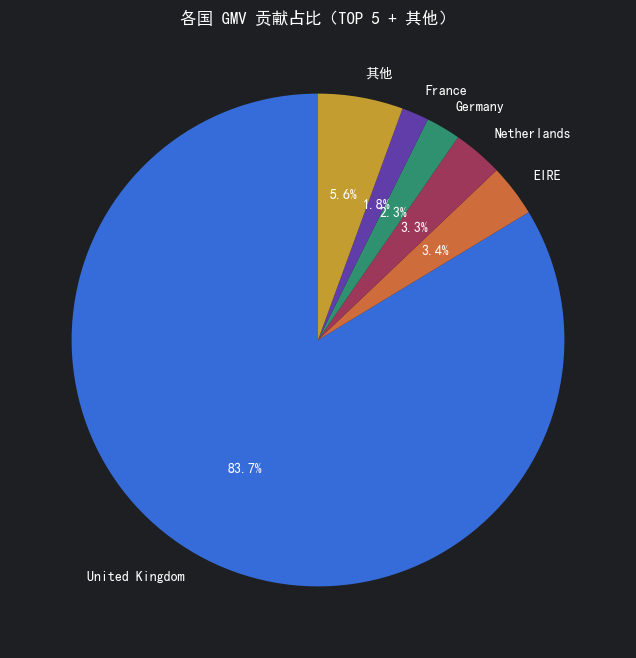

In [62]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 国家 GMV 占比
# 取 TOP 5 国家，其余合并为“其他”
top5_countries = country_gmv_pct.head(5)
others = pd.Series({'其他': country_gmv_pct[5:].sum()})
country_pie_data = pd.concat([top5_countries, others])

# 画饼图
plt.figure(figsize=(8, 8))
plt.pie(country_pie_data, labels=country_pie_data.index, autopct='%1.1f%%', startangle=90)
plt.title('各国 GMV 贡献占比（TOP 5 + 其他）')
plt.show()

##### 2.月度GMV趋势折线图

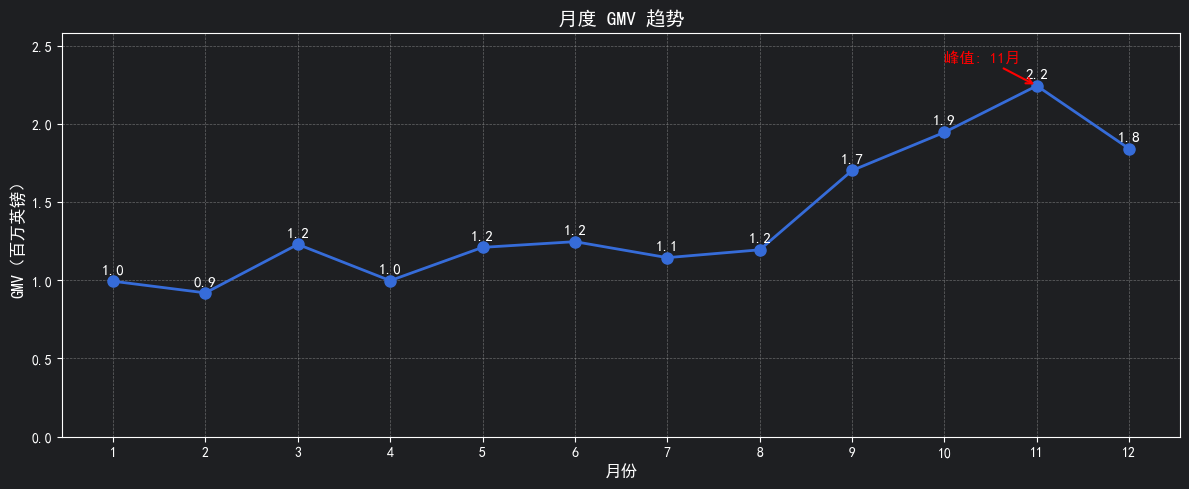

In [63]:
# 按月统计 GMV
monthly_gmv_raw = file_2.groupby('month')['total_price'].sum().sort_index()
# 将 GMV 除以 1,000,000 转换为百万英镑
monthly_gmv_millions = monthly_gmv_raw / 1_000_000

plt.figure(figsize=(12, 5))
plt.plot(monthly_gmv_millions.index, monthly_gmv_millions.values, marker='o', linewidth=2, markersize=8)
plt.title('月度 GMV 趋势', fontsize=14)
plt.xlabel('月份', fontsize=12)
plt.ylabel('GMV（百万英镑）', fontsize=12)
plt.xticks(range(1, 13))
plt.ylim(0, monthly_gmv_millions.max() * 1.15)  # 给标签留出空间
plt.grid(True, linestyle='--', alpha=0.5)

# 在每个点上添加数值标签（放在点上方）
for i, v in enumerate(monthly_gmv_millions.values):
    plt.text(i+1, v + 0.05, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

# 标注峰值
max_month = monthly_gmv_millions.idxmax()
max_value = monthly_gmv_millions.max()
plt.annotate(f'峰值: {max_month}月', xy=(max_month, max_value), xytext=(max_month-1, max_value + 0.15),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()


##### 3.各层用户GMV贡献占比饼图

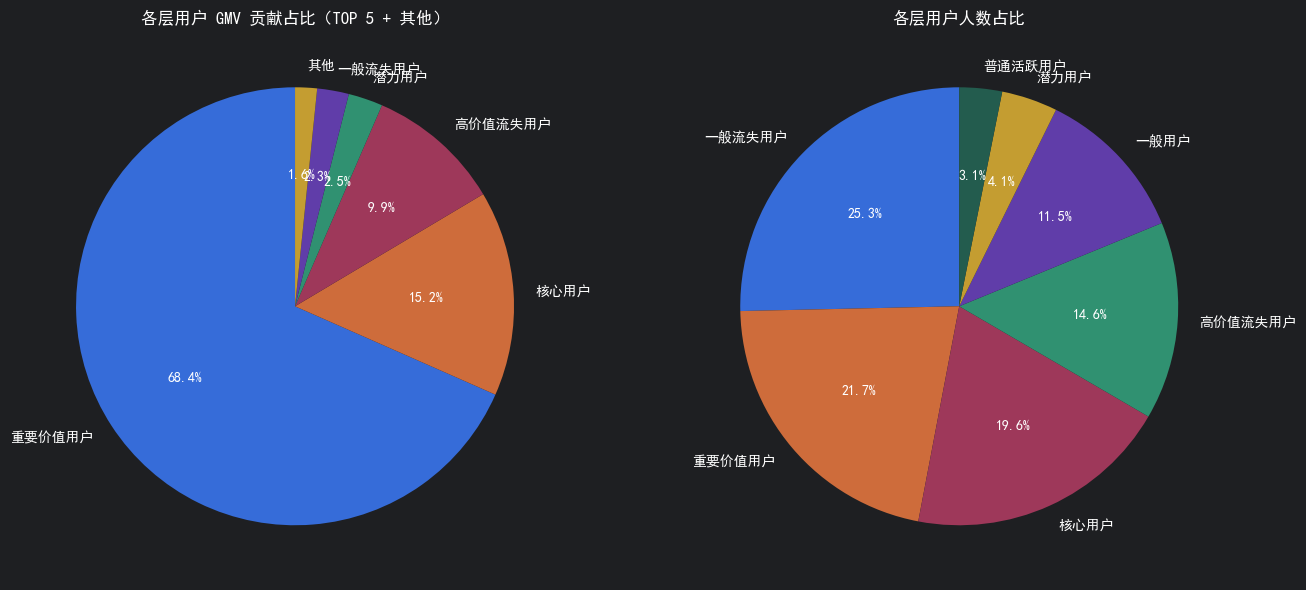

In [64]:
# 各层用户 GMV 贡献
segment_gmv = rfm.groupby('segment')['M'].sum().sort_values(ascending=False)
top5_segments = segment_gmv.head(5)
others = pd.Series({'其他': segment_gmv[5:].sum()})
pie_data = pd.concat([top5_segments, others])
# 各层用户人数占比
segment_counts = rfm['segment'].value_counts()

# 并排显示两张图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左图：GMV 贡献占比
ax1.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('各层用户 GMV 贡献占比（TOP 5 + 其他）')

# 右图：人数占比
ax2.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('各层用户人数占比')

plt.tight_layout()
plt.show()


##### 4.重要价值VS核心用户对比条形图

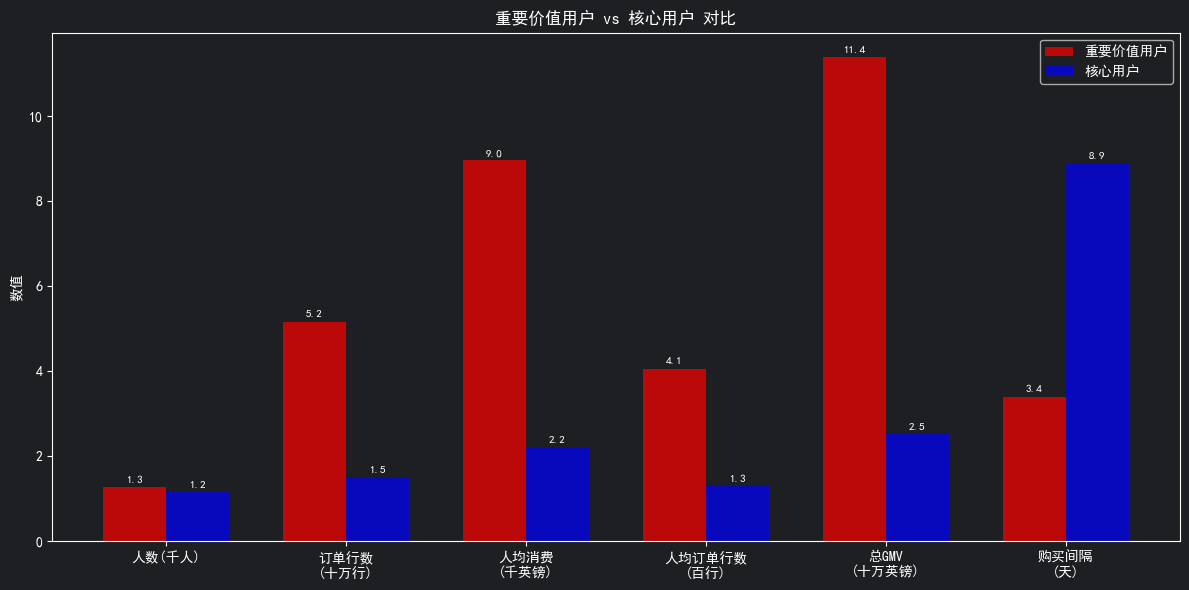

In [77]:
# 简化指标名称
metrics = ['人数(千人)', '订单行数\n(十万行)', '人均消费\n(千英镑)', '人均订单行数\n(百行)', '总GMV\n(十万英镑)', '购买间隔\n(天)']

# 重要价值用户数据（调整单位）
vip_values = [1.272, 5.165, 8.96, 4.06, 11.39491303, 3.4]

# 核心用户数据
core_values = [1.151, 1.496, 2.20, 1.30, 2.52697531, 8.9]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, vip_values, width, label='重要价值用户', color='red', alpha=0.7)
rects2 = ax.bar(x + width/2, core_values, width, label='核心用户', color='blue', alpha=0.7)

ax.set_ylabel('数值')
ax.set_title('重要价值用户 vs 核心用户 对比')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 在柱子上添加数值
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('重要价值VS核心用户(六项指标).png', dpi=300, bbox_inches='tight')
plt.show()

##### 5.RFM三维分布图

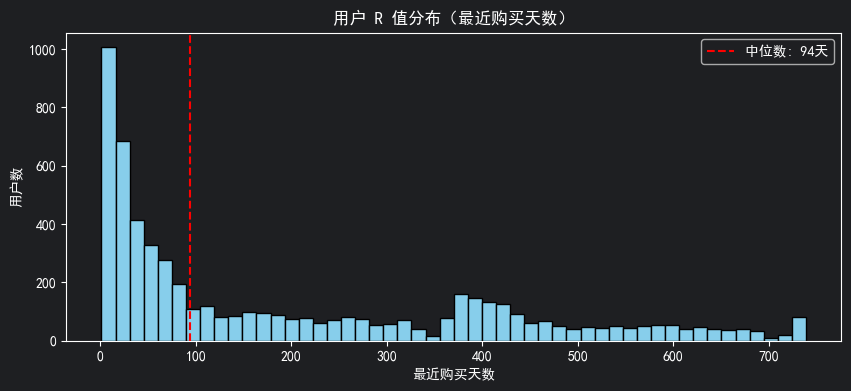

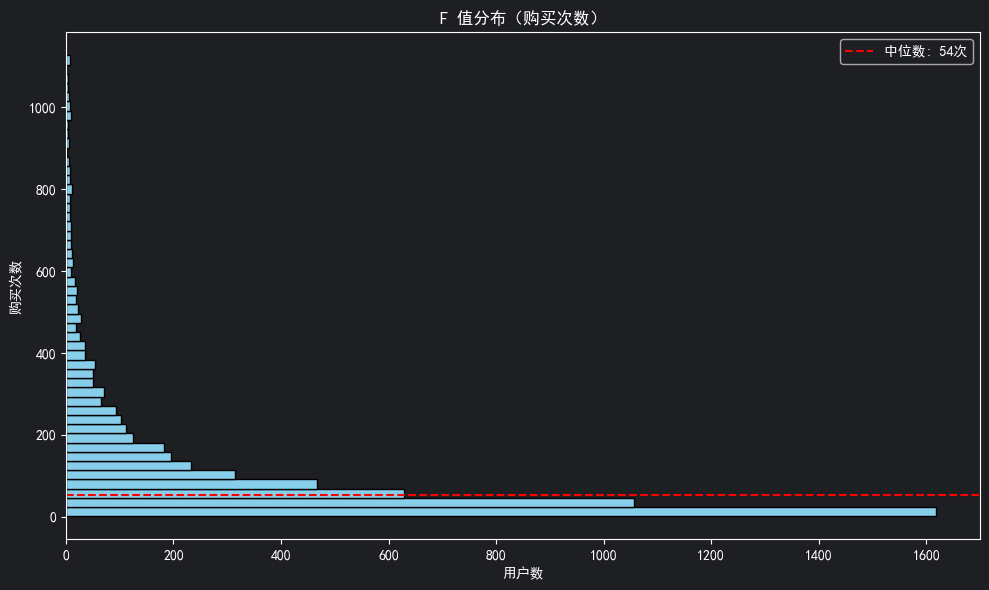

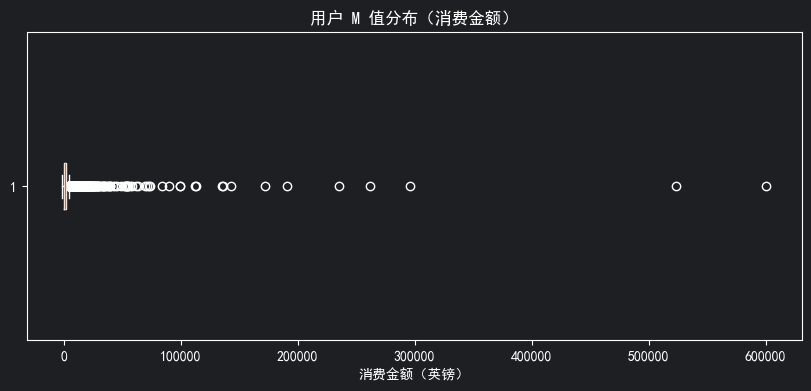

M 值分位数：
0.25      331.6000
0.50      852.2450
0.75     2207.1025
0.90     5294.6440
0.95     9127.5135
0.99    27074.5139
Name: M, dtype: float64


In [76]:
#  R 值分布直方图（最近购买天数）
plt.figure(figsize=(10, 4))
plt.hist(rfm['R'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('最近购买天数')
plt.ylabel('用户数')
plt.title('用户 R 值分布（最近购买天数）')
plt.axvline(rfm['R'].median(), color='red', linestyle='--', label=f'中位数: {rfm["R"].median():.0f}天')
plt.legend()
plt.savefig('用户R值分布直方图.png', dpi=300, bbox_inches='tight')
plt.show()

#  F 值分布直方图（购买次数）
plt.figure(figsize=(10, 6))

# 只取 99% 分位数以内的数据，避免极端值拉长
f_99 = rfm['F'].quantile(0.99)
f_filtered = rfm[rfm['F'] <= f_99]['F']

# 水平直方图
plt.hist(f_filtered, bins=50, orientation='horizontal', color='skyblue', edgecolor='black')
plt.ylabel('购买次数')
plt.xlabel('用户数')
plt.title('F 值分布（购买次数）')
plt.axhline(rfm['F'].median(), color='red', linestyle='--', label=f'中位数: {rfm["F"].median():.0f}次')
plt.legend()
plt.tight_layout()
plt.savefig('用户F值分布直方图.png', dpi=300, bbox_inches='tight')
plt.show()
#  M 值分布箱线图（消费金额）
plt.figure(figsize=(10, 4))
plt.boxplot(rfm['M'], vert=False)
plt.xlabel('消费金额（英镑）')
plt.title('用户 M 值分布（消费金额）')
plt.savefig('用户M值分布箱线图.png', dpi=300, bbox_inches='tight')
plt.show()

# 或者用分位数分段看
print("M 值分位数：")
print(rfm['M'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


#### 6.商品关联网络图

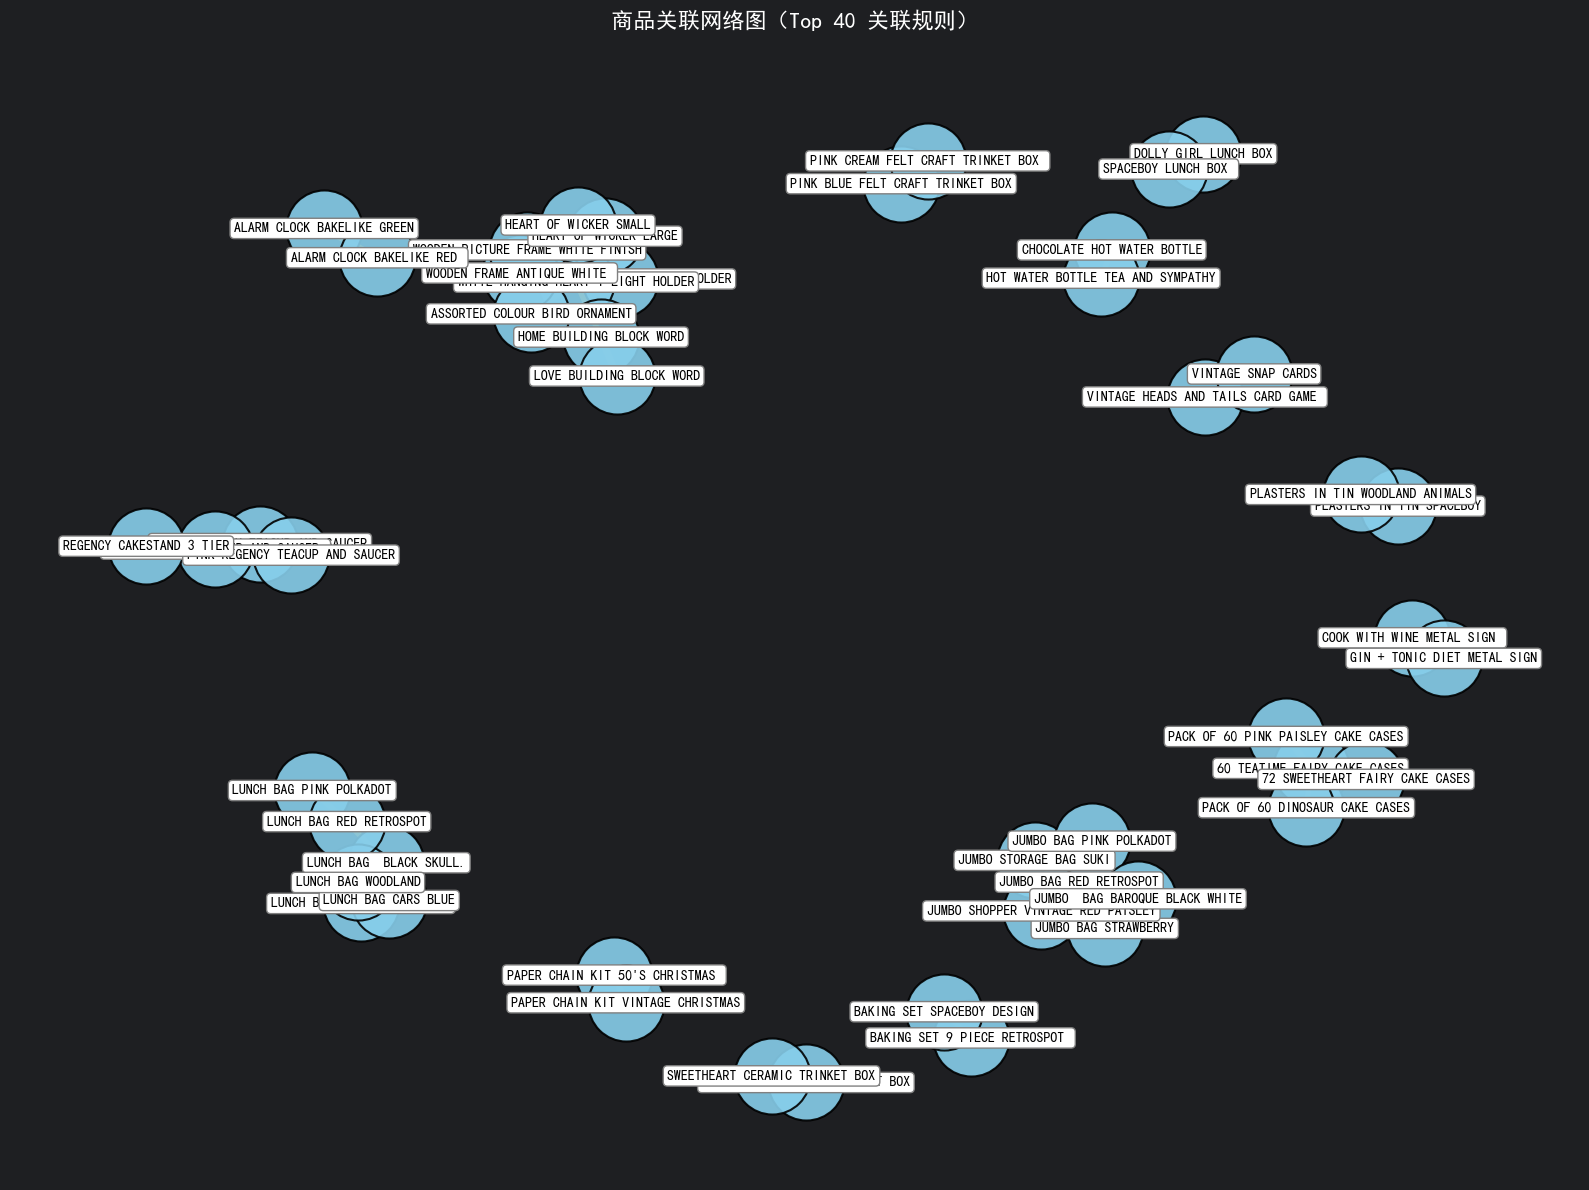

'\n关联表中的前40行数据中共这些商品\n他们按照关联规则会与经常一起被买的商品聚在一起\n不会一起被买的商品则会各自远离\n'

In [74]:
import networkx as nx
import matplotlib.pyplot as plt

# 取 Top 20 关联规则（少一点，避免太密）
top_pairs = popular_pairs.head(40)

# 创建图
G = nx.Graph()
for _, row in top_pairs.iterrows():
    G.add_edge(row['商品A'], row['商品B'], weight=row['共现次数'])

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# 画图
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=1.5, seed=42, iterations=50)

# 画节点（更大、颜色更亮）
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='#87CEEB', alpha=0.9, edgecolors='black', linewidths=1.5)

# 画边（宽度按权重缩放）
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G, pos, width=[w/150 for w in weights], alpha=0.7, edge_color='orange')

# 画标签（白色背景 + 黑色字体 + 更大字号）
labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.title('商品关联网络图（Top 40 关联规则）', fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('商品关联网络图.png', dpi=300, bbox_inches='tight')
plt.show()
"""
关联表中的前40行数据中共这些商品
他们按照关联规则会与经常一起被买的商品聚在一起
不会一起被买的商品则会各自远离
"""

#### 7.各商品GMV贡献（TOP15）柱状图


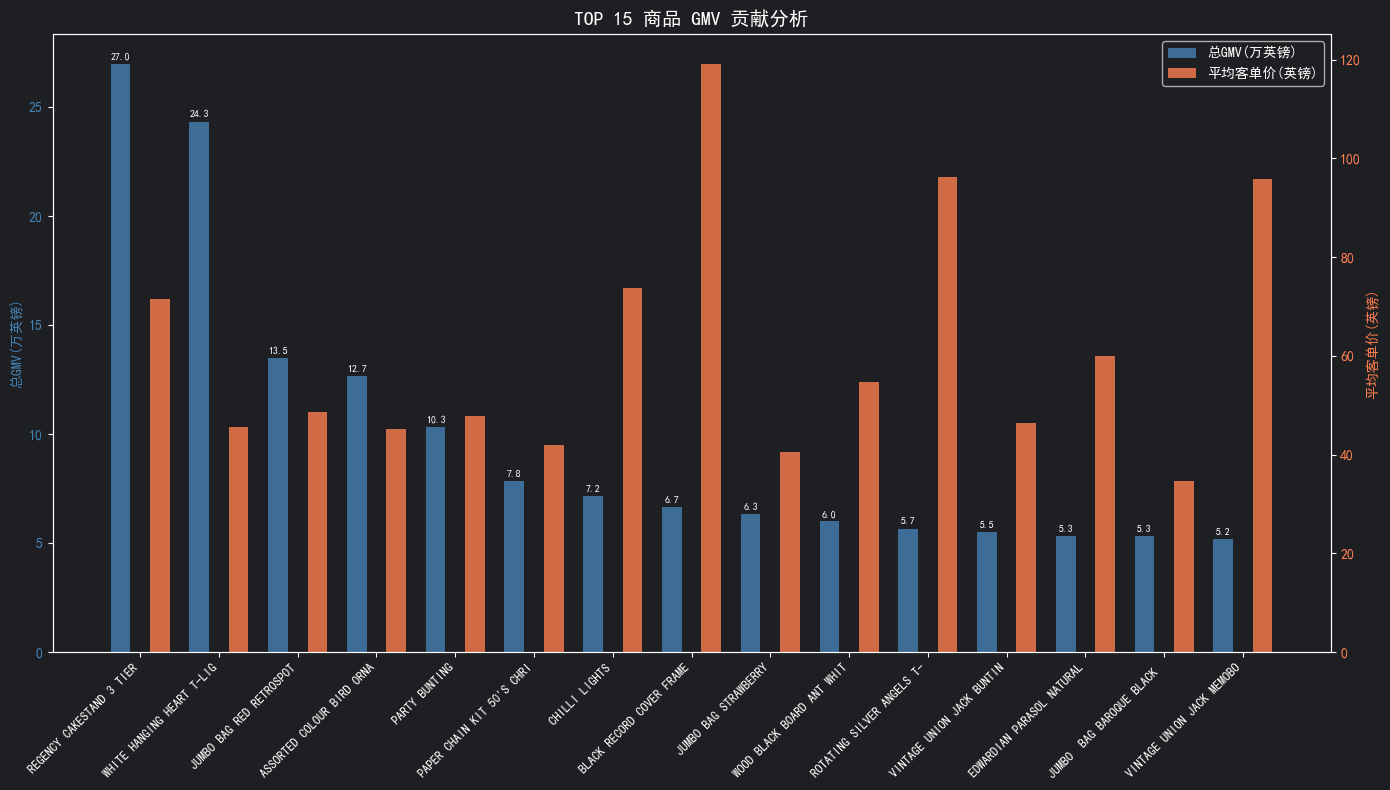

In [68]:
# 取 TOP 15 商品
top15_products = product_summary.sort_values('总GMV占比(%)', ascending=False).head(15).copy()

# 为了让柱状图可读，调整单位
top15_products['总GMV(万英镑)'] = top15_products['总GMV占比(%)'] / 100 * file_2['total_price'].sum() / 10000
top15_products['平均客单价(英镑)'] = top15_products['平均客单价(英镑)']

# 商品名称简写（取前25个字符）
top15_products['商品简称'] = top15_products.index.str[:25]

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(14, 8))

x = np.arange(len(top15_products))
width = 0.25

# 柱状图1：总GMV（万英镑）
bars1 = ax1.bar(x - width, top15_products['总GMV(万英镑)'], width, label='总GMV(万英镑)', color='steelblue', alpha=0.8)
ax1.set_ylabel('总GMV(万英镑)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# 创建第二个Y轴：平均客单价
ax2 = ax1.twinx()
bars3 = ax2.bar(x + width, top15_products['平均客单价(英镑)'], width, label='平均客单价(英镑)', color='coral', alpha=0.8)
ax2.set_ylabel('平均客单价(英镑)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# 设置X轴标签
ax1.set_xticks(x)
ax1.set_xticklabels(top15_products['商品简称'], rotation=45, ha='right', fontsize=9)
ax1.set_title('TOP 15 商品 GMV 贡献分析', fontsize=14)

# 图例合并
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# 在柱子上添加数值
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)

plt.tight_layout()
plt.show()

#### 8.热门商品复购率（TOP15）柱状图

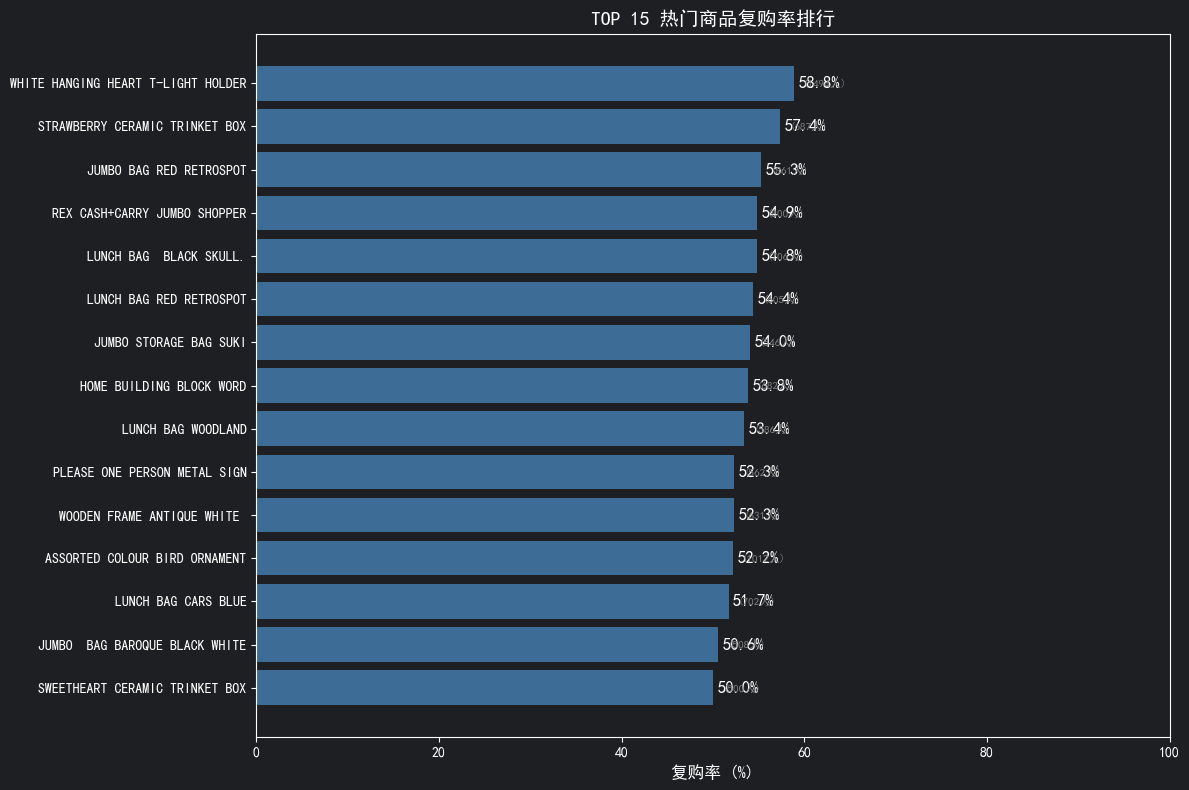

In [69]:
# 取 TOP 15 复购率商品（按复购率排序）
top15_repurchase = product_repurchase_filtered.sort_values('repurchase_rate', ascending=False).head(15).copy()

# 商品名称
top15_repurchase['商品名称'] = top15_repurchase.index

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# 画图
fig, ax = plt.subplots(figsize=(12, 8))

# 横向柱状图（复购率从高到低）
bars = ax.barh(top15_repurchase['商品名称'], top15_repurchase['repurchase_rate'], color='steelblue', alpha=0.8)

# 设置 X 轴范围 0-100%
ax.set_xlim(0, 100)

# 在柱子上添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%', xy=(width + 0.5, bar.get_y() + bar.get_height()/2),
                va='center', fontsize=12,fontweight='bold')

# 添加用户数标签（在右侧）
for i, (idx, row) in enumerate(top15_repurchase.iterrows()):
    ax.text(row['repurchase_rate'] + 1, i, f'({row["user_count"]}人)', va='center', fontsize=8, color='gray')

ax.set_xlabel('复购率 (%)', fontsize=12)
ax.set_title('TOP 15 热门商品复购率排行', fontsize=14)
ax.invert_yaxis()  # 让复购率最高的在顶部
plt.tight_layout()
plt.show()

#### 热门商品退货率TOP15

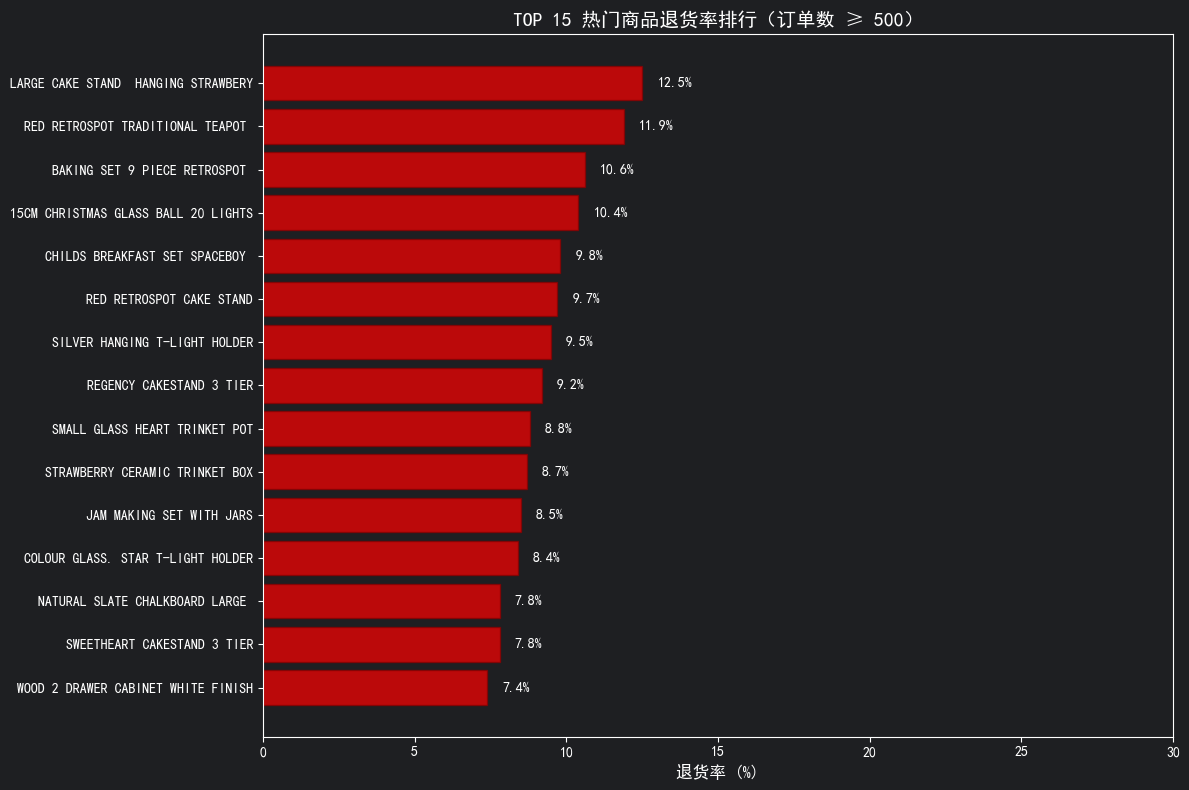

In [70]:
# 取 TOP 15 退货率商品（订单数 >= 500）
top15_return = return_rate_filtered.head(15).copy()

# 商品名称
top15_return.index = top15_return.index

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# 画图
fig, ax = plt.subplots(figsize=(12, 8))

# 横向柱状图（退货率从高到低），颜色改为红色
bars = ax.barh(top15_return.index, top15_return.values, color='red', alpha=0.7, edgecolor='darkred')

# 设置 X 轴范围 0-30
ax.set_xlim(0, 30)

# 在柱子上添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%', xy=(width + 0.5, bar.get_y() + bar.get_height()/2),
                va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('退货率 (%)', fontsize=12)
ax.set_title('TOP 15 热门商品退货率排行（订单数 ≥ 500）', fontsize=14)
ax.invert_yaxis()  # 退货率最高的在顶部
plt.tight_layout()
plt.show()

#### 导出关键图表制作关键信息

In [71]:
import pandas as pd

# 确保 file_2_pos 和 rfm 已定义
# 如果没有，先运行你的数据清洗代码

# ============================================================
# 图1：国家 GMV 贡献占比（TOP5 + 其他）
# ============================================================
country_gmv = file_2.groupby('country')['total_price'].sum().sort_values(ascending=False)
top5 = country_gmv.head(5)
others = pd.Series({'其他': country_gmv[5:].sum()})
country_pie = pd.concat([top5, others]).reset_index()
country_pie.columns = ['国家', 'GMV(英镑)']
country_pie.to_csv('图1_国家GMV贡献.csv', index=False)

# ============================================================
# 图2：月度 GMV 趋势折线图
# ============================================================
monthly_gmv = file_2.groupby('month')['total_price'].sum().reset_index()
monthly_gmv.columns = ['月份', 'GMV(英镑)']
monthly_gmv.to_csv('图2_月度GMV趋势.csv', index=False)

# ============================================================
# 图3：各层用户 GMV 占比饼图（TOP5 + 其他）
# ============================================================
segment_gmv = rfm.groupby('segment')['M'].sum().sort_values(ascending=False)
top5_seg = segment_gmv.head(5)
others_seg = pd.Series({'其他': segment_gmv[5:].sum()})
segment_gmv_pie = pd.concat([top5_seg, others_seg]).reset_index()
segment_gmv_pie.columns = ['用户分层', 'GMV(英镑)']
segment_gmv_pie.to_csv('图3_用户GMV贡献.csv', index=False)

# ============================================================
# 图4：各层用户人数占比饼图
# ============================================================
segment_counts = rfm['segment'].value_counts().reset_index()
segment_counts.columns = ['用户分层', '人数']
segment_counts.to_csv('图4_用户人数占比.csv', index=False)

# ============================================================
# 图5：重要价值用户 vs 核心用户 对比条形图
# ============================================================
# 提取两类用户数据
vip = rfm[rfm['segment'] == '重要价值用户']
core = rfm[rfm['segment'] == '核心用户']

vip_stats = {
    '用户类型': '重要价值用户',
    '人数(千人)': len(vip) / 1000,
    '订单行数(十万行)': vip['F'].sum() / 100000,
    '人均GMV(千英镑)': (vip['M'].sum() / len(vip)) / 1000,
    '人均订单行数(百行)': (vip['F'].sum() / len(vip)) / 100,
    '总GMV(十万英镑)': vip['M'].sum() / 100000,
    '购买间隔(天)': vip['R'].mean()
}

core_stats = {
    '用户类型': '核心用户',
    '人数(千人)': len(core) / 1000,
    '订单行数(十万行)': core['F'].sum() / 100000,
    '人均GMV(千英镑)': (core['M'].sum() / len(core)) / 1000,
    '人均订单行数(百行)': (core['F'].sum() / len(core)) / 100,
    '总GMV(十万英镑)': core['M'].sum() / 100000,
    '购买间隔(天)': core['R'].mean()
}

compare_df = pd.DataFrame([vip_stats, core_stats])
compare_df.to_csv('图5_用户对比.csv', index=False)

# ============================================================
# 图6：R 值分布直方图 + F 值分布直方图 + M 值箱线图
# ============================================================
# R 值分布数据（用于直方图）
r_dist = rfm['R'].value_counts().sort_index().reset_index()
r_dist.columns = ['R(最近购买天数)', '用户数']
r_dist.to_csv('图6a_R值分布.csv', index=False)

# F 值分布数据（用于直方图）
f_dist = rfm['F'].value_counts().sort_index().reset_index()
f_dist.columns = ['F(购买次数)', '用户数']
f_dist.to_csv('图6b_F值分布.csv', index=False)

# M 值数据（用于箱线图，只需要一列数值）
m_values = rfm[['M']].copy()
m_values.columns = ['消费金额(英镑)']
m_values.to_csv('图6c_M值箱线图.csv', index=False)

# ============================================================
# 图7：商品关联网络图（取前40行关联）
# ============================================================
# 需要先有 popular_pairs（你之前商品关联分析的结果）
if 'popular_pairs' in locals():
    top40_pairs = popular_pairs.head(40).copy()
    top40_pairs.to_csv('图7_商品关联网络.csv', index=False)
else:
    print("请先运行商品关联分析代码，生成 popular_pairs")

# ============================================================
# 图8：商品 GMV 贡献 TOP 15
# ============================================================
product_gmv = file_2.groupby('description')['total_price'].sum().sort_values(ascending=False).head(15).reset_index()
product_gmv.columns = ['商品', '总GMV(英镑)']
# 添加平均客单价
product_orders = file_2.groupby('description').size()
product_gmv['平均客单价(英镑)'] = product_gmv['总GMV(英镑)'] / product_orders[product_gmv['商品']].values
product_gmv.to_csv('图8_商品GMV贡献TOP15.csv', index=False)

# ============================================================
# 图9：复购率 TOP 15 热门商品（购买用户数 >= 500）
# ============================================================
# 需要先有 product_repurchase_filtered
if 'product_repurchase_filtered' in locals():
    repurchase_top15 = product_repurchase_filtered[product_repurchase_filtered['user_count'] >= 500]
    repurchase_top15 = repurchase_top15.sort_values('repurchase_rate', ascending=False).head(15).reset_index()
    repurchase_top15.columns = ['商品', '复购率(%)', '用户数']
    repurchase_top15.to_csv('图9_商品复购率TOP15.csv', index=False)
else:
    print("请先运行商品复购率分析代码")

# ============================================================
# 图10：退货率 TOP 15 热门商品（订单数 >= 500）
# ============================================================
# 需要先有 return_rate_filtered
if 'return_rate_filtered' in locals():
    return_top15 = return_rate_filtered.head(15).reset_index()
    return_top15.columns = ['商品', '退货率(%)']
    return_top15.to_csv('图10_商品退货率TOP15.csv', index=False)
else:
    print("请先运行商品退货率分析代码")

print("所有 CSV 已导出完成！共生成 10+ 个文件")

所有 CSV 已导出完成！共生成 10+ 个文件
